# Sistema de Análisis del Mercado de Automoción

### Crisitian Cabrera Pinto y Álex Rafael de la Cruz Sánchez

Trabajo SBD y SAA

In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
#Lectura de ficheros
df_vehiculos = pd.read_csv('vehiculos.json')
df_ventas_mantenimiento = pd.read_csv('ventas_mantenimiento.csv')
df_opiniones = pd.read_csv('opiniones_clientes.xml')

In [3]:
df_vehiculos.head()

,vehiculo_id,marca,modelo,anio_fabricacion,combustible,transmision,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento
0,VH001,Peugeot,208,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
1,VH002,Hyundai,i20,2018,Gasolina,Manual,219,2000,4.1,4.1,149,36500,Sedán
2,VH003,Kia,Ev6,2020,Híbrido,Manual,130,2200,5.7,4.3,107,34800,Deportivo
3,VH004,Ford,Puma,2018,Gasolina,Automática,178,2000,5.1,3.6,138,35200,SUV
4,VH005,Hyundai,i20,2022,Gasolina,Automática,237,1400,6.8,3.6,109,38800,SUV


In [4]:
df_ventas_mantenimiento.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098


In [5]:
df_opiniones.head()

,review_id,vehiculo_id,cliente_id,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad,recomendacion,texto_review
0,RV001,VH204,CUST173,3.4,3.4,3.9,4.8,3.6,3.0,No,"Problemático, poco espacio"
1,RV002,VH249,CUST034,3.0,3.1,3.4,4.1,2.9,2.6,No,"Decepcionante, poco espacio"
2,RV003,VH244,CUST038,5.0,5.0,5.0,5.0,5.0,5.0,Si,"Eficiente vehículo, gran rendimiento"
3,RV004,VH280,CUST022,3.9,3.9,3.9,4.8,3.5,3.1,Si,"Problemático, precio elevado"
4,RV005,VH125,CUST153,4.0,4.2,4.5,4.2,4.1,5.0,Si,"Lento, precio elevado"


### Fase 0: Datos

¿Que datos tiene el fichero de vehiculos?

In [6]:
df_vehiculos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vehiculo_id          300 non-null    object 
 1   marca                300 non-null    object 
 2   modelo               300 non-null    object 
 3   anio_fabricacion     300 non-null    int64  
 4   combustible          300 non-null    object 
 5   transmision          300 non-null    object 
 6   potencia_cv          300 non-null    int64  
 7   cilindrada           300 non-null    int64  
 8   consumo_urbano       300 non-null    float64
 9   consumo_extraurbano  300 non-null    float64
 10  emisiones_co2        300 non-null    int64  
 11  precio_base          300 non-null    int64  
 12  segmento             300 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 30.6+ KB


In [7]:
df_vehiculos.shape

(300, 13)

¿Qué datos tiene el fichero de venta y mantenimientos?

In [8]:
df_ventas_mantenimiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   venta_id                   600 non-null    object
 1   vehiculo_id                600 non-null    object
 2   fecha_venta                600 non-null    object
 3   region_vendedor            600 non-null    object
 4   precio_venta_real          600 non-null    int64 
 5   kilometraje_venta          600 non-null    int64 
 6   servicios_realizados       600 non-null    int64 
 7   coste_mantenimiento_anual  600 non-null    int64 
 8   incidencias_mecanicas      600 non-null    int64 
 9   valor_residual_estimado    600 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 47.0+ KB


In [9]:
df_ventas_mantenimiento.shape

(600, 10)

¿Qué datos tiene el fichero de opiniones?

In [10]:
df_opiniones.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   review_id            500 non-null    object 
 1   vehiculo_id          500 non-null    object 
 2   cliente_id           500 non-null    object 
 3   puntuacion_conjunta  500 non-null    float64
 4   confort              500 non-null    float64
 5   seguridad            500 non-null    float64
 6   eficiencia           500 non-null    float64
 7   diseno               500 non-null    float64
 8   fiabilidad           500 non-null    float64
 9   recomendacion        500 non-null    object 
 10  texto_review         500 non-null    object 
dtypes: float64(6), object(5)
memory usage: 43.1+ KB


In [11]:
df_opiniones.shape

(500, 11)

### Fase 1: Selección y comprensión del dominio

### 1.1 Análisis Exploratorio del Dominio

### Análisis de la distribución de marcas, modelos y segmentos

    Distribución de marcas

In [12]:
df_vehiculos['marca'].value_counts()

marca
Kia           32
Peugeot       29
Ford          29
Toyota        28
Citroën       28
BMW           27
Mercedes      25
Renault       24
Hyundai       22
Audi          19
Volkswagen    19
Seat          18
Name: count, dtype: int64

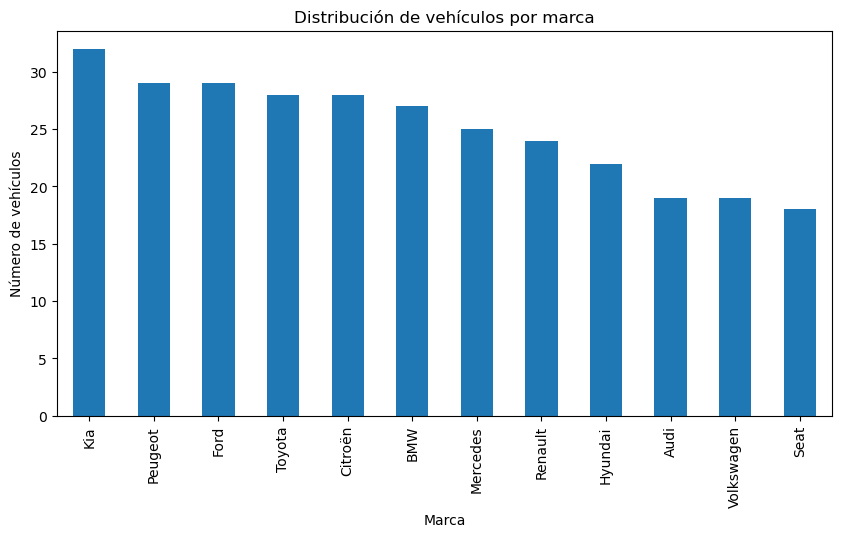

In [13]:
df_vehiculos['marca'].value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Distribución de vehículos por marca'
)
plt.ylabel('Número de vehículos')
plt.xlabel('Marca')
plt.show()

Se observa una distribución relativamente equilibrada entre las distintas marcas, sin una dominancia extrema de una sola de ellas.
Marcas generalistas como Kia, Peugeot, Ford y Toyota presentan una mayor frecuencia.

    Distribución de modelos

In [14]:
df_vehiculos['modelo'].value_counts().head(10)

modelo
X1         14
Mondeo     11
Niro       10
Ev6        10
Clase E    10
Polo        9
408         9
Q3          8
Corolla     8
RAV4        8
Name: count, dtype: int64

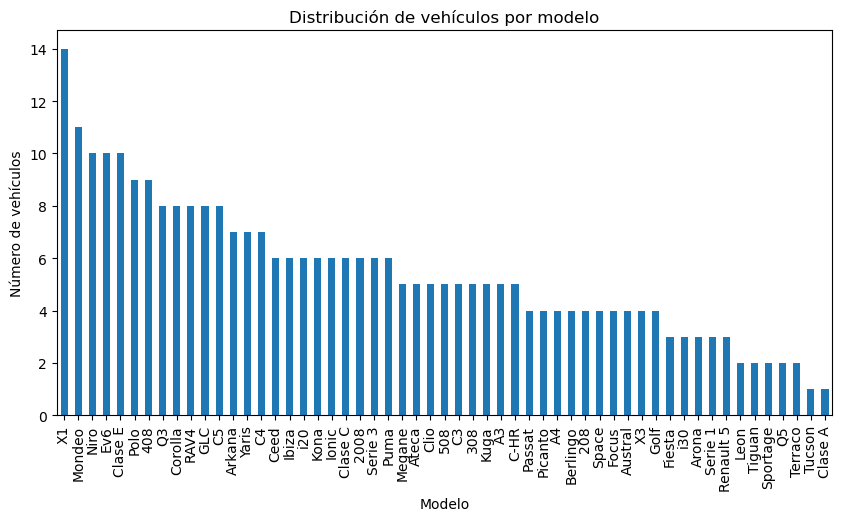

In [15]:
df_vehiculos['modelo'].value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Distribución de vehículos por modelo'
)
plt.ylabel('Número de vehículos')
plt.xlabel('Modelo')
plt.show()

La distribución de modelos muestra que algunos vehículos concretos aparecen con mayor frecuencia, aunque no existe una concentración excesiva en un único modelo.

    Distribución por segmento

In [16]:
df_vehiculos['segmento'].value_counts()

segmento
Compacto     102
SUV           86
Sedán         58
Executive     38
Deportivo     16
Name: count, dtype: int64

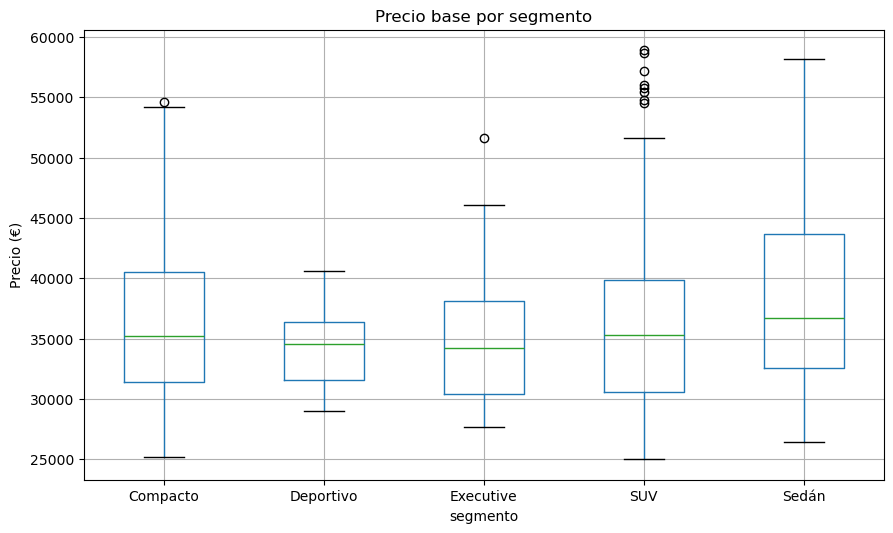

In [17]:
df_vehiculos.boxplot(
    column='precio_base',
    by='segmento',
    figsize=(10,6)
)
plt.title('Precio base por segmento')
plt.suptitle('')
plt.ylabel('Precio (€)')
plt.show()

El segmento Compacto es el más representado, seguido por los SUV, lo que refleja tendencias habituales del mercado automovilístico.
Los segmentos Executive y Deportivo presentan menor frecuencia, lo que indica que estos vehículos son menos comunes en el mercado, pero relevantes para analizar precios elevados y valores residuales.

### Relación entre características técnicas y precios

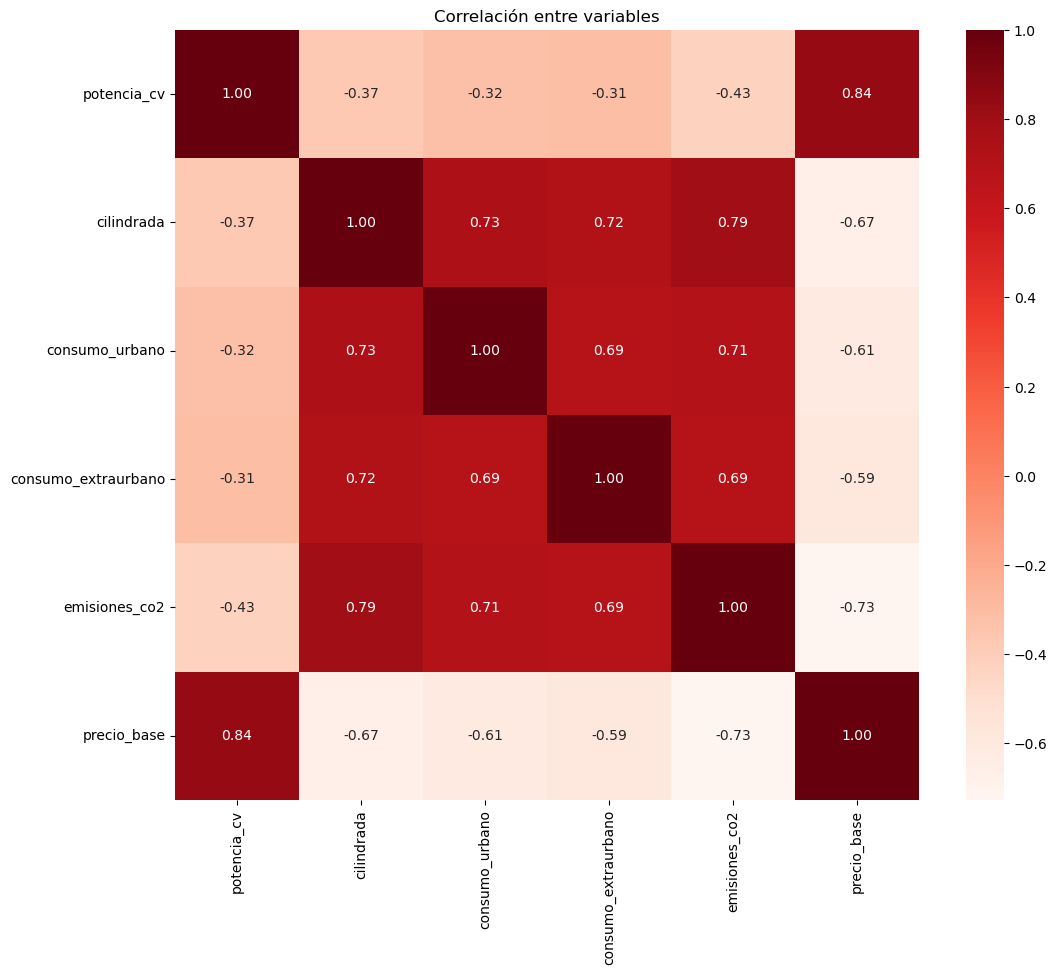

In [18]:
from pandas.plotting import scatter_matrix
import seaborn as sns
relaccion = df_vehiculos[['potencia_cv',
              'cilindrada',
              'consumo_urbano',
              'consumo_extraurbano',
              'emisiones_co2',
              'precio_base']]

cor = relaccion.corr()

plt.figure(figsize=(12,10))
sns.heatmap(cor, annot=True, fmt=".2f", cmap=plt.cm.Reds)  # mostramos solo 2 decimales
plt.title('Correlación entre variables')
plt.show()

El objetivo de esta matriz de correlación es identificar relaciones lineales entre las principales características técnicas de los vehículos y su precio base, con el fin de detectar variables potencialmente relevantes para el análisis.

    Relaccion fuerte entre: potencia_cv y precio_base (0.84)
Los vehículos con mayor potencia tienden a presentar precios base más elevados, lo que indica que las prestaciones del motor son un factor determinante en el valor del vehículo.

    Relaccion negativa entre: cilindrada y precio_base (-0.67)
Una mayor cilindrada no implica necesariamente un mayor precio base.

    Relaccion negativa entre: cilindrada y precio_base (-0.67)
Una mayor cilindrada no implica necesariamente un mayor precio base.

    Relaccion negativa entre: Precio base y consumo_urbano (-0.61)
    Relaccion negativa entre: Precio base y consumo_extraurbano (-0.59)
Los vehículos con menores consumos tienden a tener precios base más altos.

    Relaccion negativa entre: emisiones_co2 y precio_base (-0.73)
Vehículos con menores emisiones presentan precios base más elevados.

    Relaccion fuerte entre: cilindrada y consumo_urbano (0,73) / consumo_extraurbano (0,72)
    Relaccion negativa entre: potencia_cv y consumos (-0,31|-0,32) / emisiones (-0,43)
Estas relaciones indican que la potencia no depende únicamente de la cilindrada, y que existen vehículos de alta potencia con tecnologías más eficientes, como híbridos o eléctricos.

    Conclusión
El análisis de correlación muestra que el precio base del vehículo está fuertemente relacionado con la potencia y, de forma inversa, con el consumo y las emisiones de CO₂.
Estas relaciones sugieren que las prestaciones del motor y la eficiencia energética son factores clave en la valoración económica de los vehículos, justificando su inclusión en modelos predictivos en fases posteriores.

### Patrones de ventas y mantenimiento

In [19]:
df_ventas_mantenimiento[['precio_venta_real',
                          'kilometraje_venta',
                          'coste_mantenimiento_anual',
                          'incidencias_mecanicas']].describe()

,precio_venta_real,kilometraje_venta,coste_mantenimiento_anual,incidencias_mecanicas
count,600.000000,600.000000,600.000000,600.000000
mean,34625.320000,26835.851667,870.370000,0.463333
std,7230.237142,14023.227856,173.518137,0.943472
min,21773.000000,55.000000,542.000000,0.000000
25%,29492.250000,14661.000000,734.000000,0.000000
50%,33160.500000,27763.000000,852.000000,0.000000
75%,38418.000000,38716.000000,992.000000,0.000000
max,61242.000000,49936.000000,1478.000000,3.000000


Aqui se puede ver una amplia variabilidad en el precio de venta y el kilometraje, indicando la presencia de vehículos con distintos niveles de uso.

El número medio de incidencias mecánicas es bajo, lo que sugiere que la mayoría de los vehículos no presenta averías frecuentes.

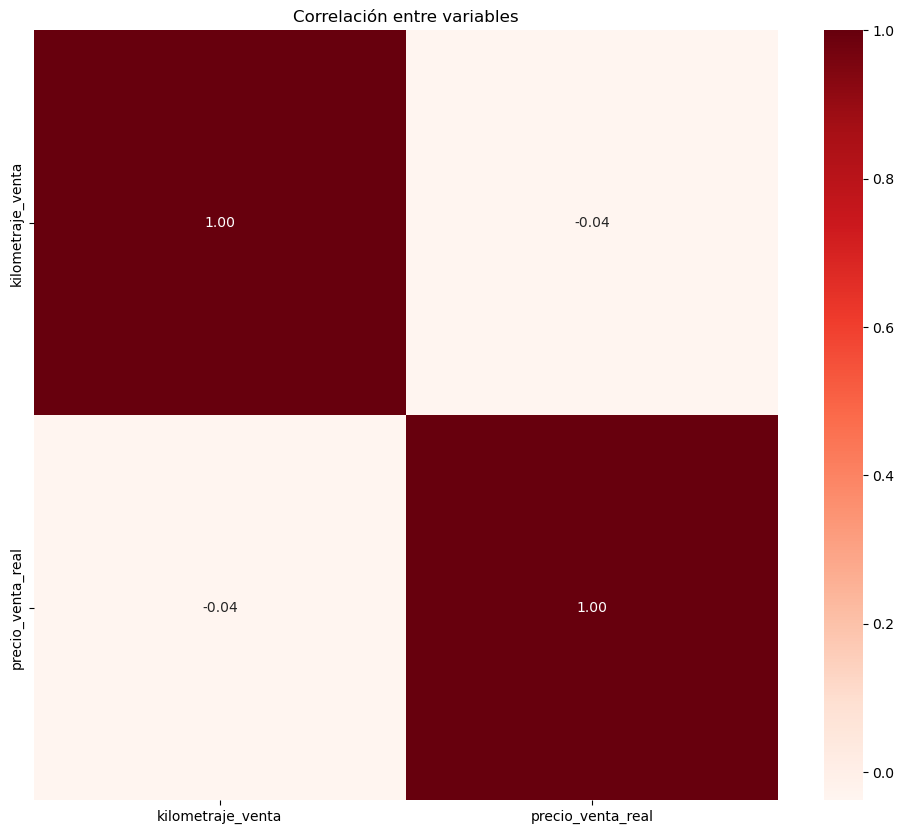

In [20]:
cor = df_ventas_mantenimiento[['kilometraje_venta', 'precio_venta_real']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(cor, annot=True, fmt=".2f", cmap=plt.cm.Reds)  # mostramos solo 2 decimales
plt.title('Correlación entre variables')
plt.show()


La correlación entre el kilometraje y el precio de venta real es muy débil y cercana a cero, lo que indica que, en este conjunto de datos, el kilometraje por sí solo no explica de forma significativa el precio de venta.

In [21]:
df_ventas_mantenimiento.merge(
    df_vehiculos[['vehiculo_id', 'marca']],
    on='vehiculo_id',
    how='left'
).groupby('marca')['coste_mantenimiento_anual'].mean().sort_values(ascending=False)

marca
BMW           942.413793
Audi          892.648649
Hyundai       889.583333
Ford          885.586207
Mercedes      883.574468
Peugeot       873.000000
Toyota        864.928571
Seat          853.388889
Kia           846.596491
Renault       842.901961
Volkswagen    838.540541
Citroën       824.169492
Name: coste_mantenimiento_anual, dtype: float64

Se observan diferencias claras en el coste medio de mantenimiento entre marcas.
Las marcas de gama mas alta presentan costes de mantenimiento más elevados, mientras que las marcas mas baratas tienden a mostrar costes inferiores.

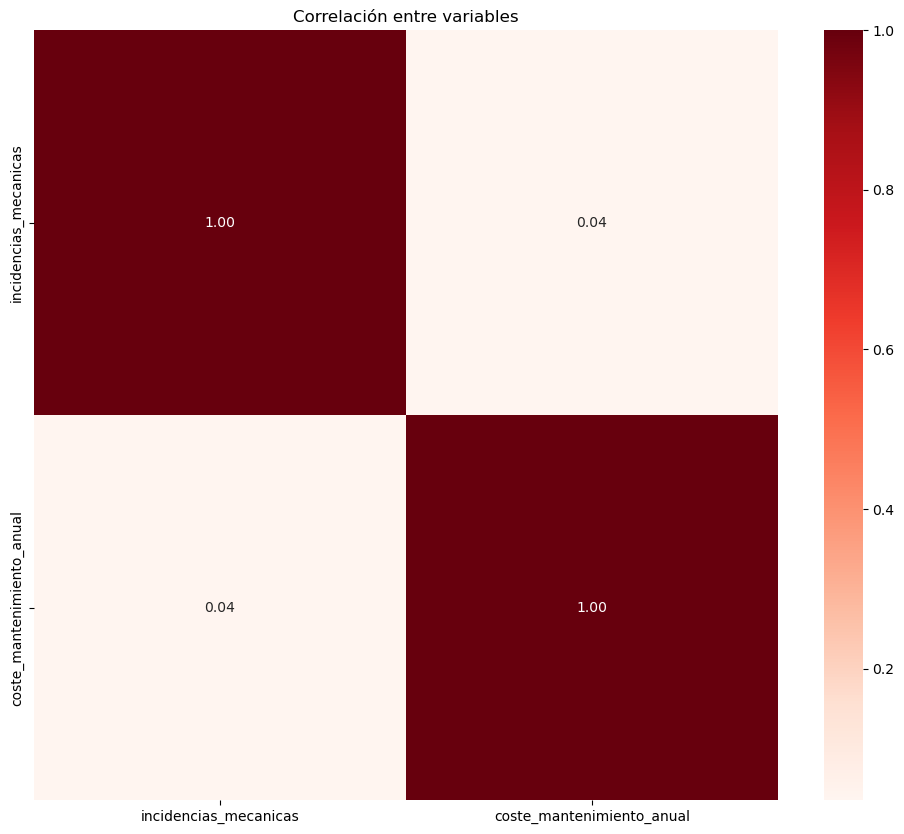

In [22]:
cor = df_ventas_mantenimiento[['incidencias_mecanicas',
                          'coste_mantenimiento_anual']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(cor, annot=True, fmt=".2f", cmap=plt.cm.Reds)  # mostramos solo 2 decimales
plt.title('Correlación entre variables')
plt.show()

La relación entre el número de incidencias mecánicas y el coste de mantenimiento anual es débil, lo que sugiere que los costes de mantenimiento no dependen únicamente del número de averías.

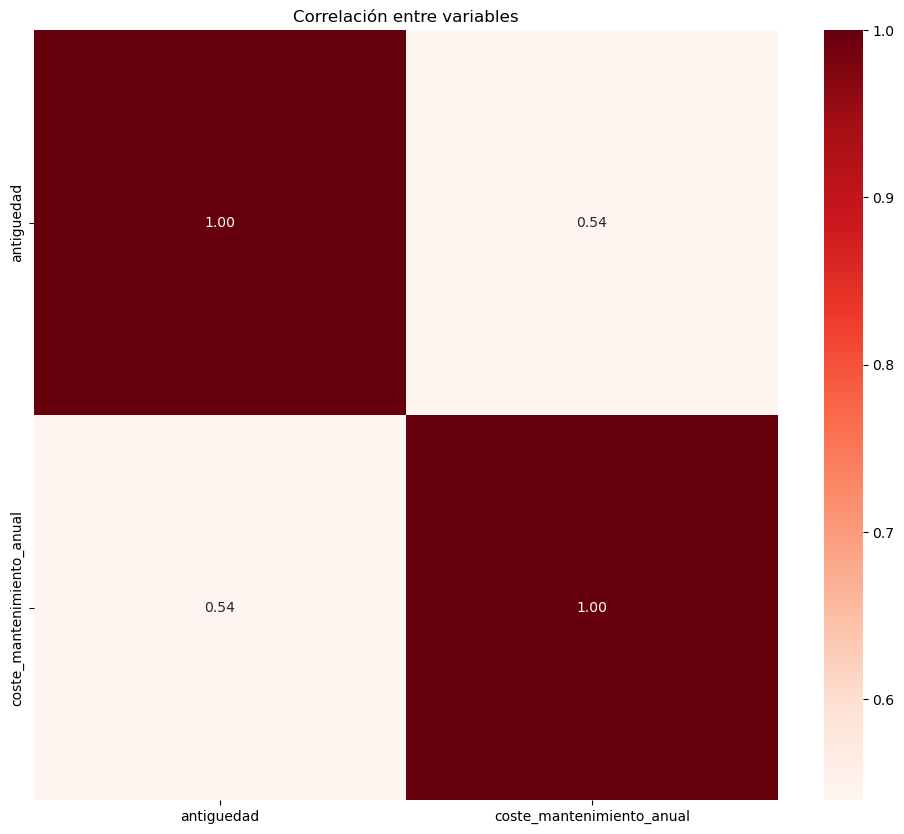

In [23]:
anio_actual = 2026

df_vehiculos['antiguedad'] = anio_actual - df_vehiculos['anio_fabricacion']

cor = df_ventas_mantenimiento.merge(
    df_vehiculos[['vehiculo_id', 'antiguedad']],
    on='vehiculo_id',
    how='left'
)[['antiguedad', 'coste_mantenimiento_anual']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(cor, annot=True, fmt=".2f", cmap=plt.cm.Reds)  # mostramos solo 2 decimales
plt.title('Correlación entre variables')
plt.show()

Se observa una correlación positiva moderada entre la antigüedad del vehículo y el coste de mantenimiento anual, indicando que los vehículos más antiguos tienden a requerir mayores gastos de mantenimiento.

### Hipótesis sobre factores que afectan al valor residual

- Se ha observado una correlación positiva moderada entre la antigüedad del vehículo y el coste de mantenimiento, lo que sugiere un mayor desgaste y una menor percepción de valor en vehículos más antiguos.

- Aunque la correlación directa entre kilometraje y precio de venta es débil en esta fase, el kilometraje sigue siendo un indicador del uso del vehículo y, combinado con otras variables, puede influir en el valor.

- Las diferencias observadas en el coste de mantenimiento por marca y su relación con la antigüedad indican que los costes de mantenimiento pueden afectar negativamente a la percepción de valor del vehículo

- Aunque la correlación directa es débil, las incidencias mecánicas reflejan problemas de fiabilidad que pueden influir en el precio de venta y en el valor residual a largo plazo.

- El análisis de correlación entre variables técnicas y precio base muestra que la eficiencia energética y las prestaciones influyen positivamente en la valoración económica del vehículo.

- Las puntuaciones y recomendaciones reflejan la satisfacción del cliente y pueden influir en la demanda y en el valor del vehículo.

### 1.2 Definición de Objetivos de Minería

    ¿Qué características determinan el precio de un vehículo?
Se plantea analizar qué variables técnicas (potencia, consumo, emisiones), comerciales (segmento, marca) y de percepción del cliente influyen de forma significativa en el precio del vehículo.

    ¿Podemos segmentar vehículos por perfil de uso y eficiencia?
Se propone segmentar los vehículos en función de su perfil de uso y eficiencia energética, utilizando variables como consumo, emisiones, tipo de combustible y kilometraje.

    ¿Qué factores predicen los costes de mantenimiento?
Se analizará la relación entre antigüedad, kilometraje, incidencias mecánicas, marca y costes de mantenimiento anual para identificar los factores que influyen en el gasto de mantenimiento.

    ¿Existen patrones en las ventas por temporada y región?
Se estudiarán posibles patrones temporales y geográficos en las ventas de vehículos, considerando la fecha de venta y la región del vendedor.

    ¿Cómo predecir el valor residual de un vehículo?
Se plantea la construcción de modelos predictivos que permitan estimar el valor residual del vehículo a partir de características técnicas, de uso, mantenimiento y percepción del cliente.

    ¿Influye la percepción del cliente en el precio del vehículo?
Dado que se dispone de información sobre valoraciones y recomendaciones de los clientes, resulta relevante analizar si estas opiniones del vehículo influyen en su valor.

    ¿Es posible detectar vehículos con precios anormales a partir de sus características?
Posibilidad de identificar vehículos con precios anormales mediante el uso de técnicas de detección de anomalías basadas en características técnicas, de uso y de mantenimiento.

### Fase 2: Preprocesamiento y limpieza

#### - Integración de múltiples fuentes 

In [24]:
# Unificación de los dataframes
df_ventas_vehiculo = pd.merge(df_ventas_mantenimiento, df_vehiculos, on="vehiculo_id", how="left")

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,combustible,transmision,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,antiguedad
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto,8
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto,8
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto,8
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,Gasolina,Manual,219,2000,4.1,4.1,149,36500,Sedán,8
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,Híbrido,Manual,130,2200,5.7,4.3,107,34800,Deportivo,6


Para la construcción del dataset unificado, se ha priorizado la integridad transaccional de los datos de ventas.

- Integración Ventas-Vehículos: Se ha realizado una unión (Left Join) entre el histórico de ventas y el catálogo de vehículos. Dado que la cardinalidad es de N:1 (muchas ventas pueden referirse al mismo modelo de coche), esta operación es segura y enriquece cada venta con sus especificaciones técnicas sin alterar el número de registros (600 transacciones).
- Hemos decidido no integrar físicamente la tabla de opiniones en esta fase preliminar. El motivo es la naturaleza "uno a muchos" de las reseñas (un vehículo tiene múltiples opiniones). Una unión directa duplicaría los registros de ventas, introduciendo sesgo en los futuros modelos de predicción de precios. Y si se tratara de unir haciendo medias y modas se perdería el texto de las reseñas.

Trabajaremos con un dataset de ventas y vehiculos para los modelos numéricos y agruparemos con las opiniones en los apartados que requieran de ellas y en las que se requiera.

In [25]:
df_ventas_vehiculo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   venta_id                   600 non-null    object 
 1   vehiculo_id                600 non-null    object 
 2   fecha_venta                600 non-null    object 
 3   region_vendedor            600 non-null    object 
 4   precio_venta_real          600 non-null    int64  
 5   kilometraje_venta          600 non-null    int64  
 6   servicios_realizados       600 non-null    int64  
 7   coste_mantenimiento_anual  600 non-null    int64  
 8   incidencias_mecanicas      600 non-null    int64  
 9   valor_residual_estimado    600 non-null    int64  
 10  marca                      600 non-null    object 
 11  modelo                     600 non-null    object 
 12  anio_fabricacion           600 non-null    int64  
 13  combustible                600 non-null    object 

In [26]:
#Valores realistas
df_ventas_vehiculo.describe()

,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,anio_fabricacion,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,antiguedad
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,34625.320000,26835.851667,3.016667,870.370000,0.463333,21677.175000,2021.211667,179.285000,1475.333333,5.390167,4.530500,105.101667,36547.666667,4.788333
std,7230.237142,14023.227856,2.038786,173.518137,0.943472,10559.684987,1.954456,53.542461,707.266049,1.773451,1.233189,49.728022,7307.009091,1.954456
min,21773.000000,55.000000,0.000000,542.000000,0.000000,5340.000000,2018.000000,90.000000,0.000000,1.500000,1.800000,0.000000,25000.000000,2.000000
25%,29492.250000,14661.000000,1.000000,734.000000,0.000000,13263.750000,2019.000000,134.000000,1200.000000,4.500000,3.900000,92.000000,31150.000000,3.000000
50%,33160.500000,27763.000000,3.000000,852.000000,0.000000,19264.500000,2021.000000,174.000000,1600.000000,5.600000,4.600000,120.000000,35150.000000,5.000000
75%,38418.000000,38716.000000,5.000000,992.000000,0.000000,28073.250000,2023.000000,217.000000,2000.000000,6.800000,5.500000,140.000000,39700.000000,7.000000
max,61242.000000,49936.000000,6.000000,1478.000000,3.000000,58200.000000,2024.000000,336.000000,2200.000000,8.000000,6.500000,160.000000,58900.000000,8.000000


In [27]:
df_opiniones.describe()

,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad
count,500.00000,500.000000,500.000000,500.00000,500.00000,500.000000
mean,3.75940,3.731000,3.935800,3.75120,3.63300,3.619600
std,0.79785,0.900289,0.850685,0.92802,0.99228,0.918359
min,1.00000,1.000000,1.000000,1.00000,1.00000,1.000000
25%,3.20000,3.200000,3.375000,3.10000,3.00000,2.900000
50%,3.80000,3.800000,4.000000,3.80000,3.70000,3.700000
75%,4.40000,4.400000,4.600000,4.50000,4.40000,4.400000
max,5.00000,5.000000,5.000000,5.00000,5.00000,5.000000


In [28]:
#Comprobación de valores nulos
df_ventas_vehiculo.isnull().sum()

venta_id                     0
vehiculo_id                  0
fecha_venta                  0
region_vendedor              0
precio_venta_real            0
kilometraje_venta            0
servicios_realizados         0
coste_mantenimiento_anual    0
incidencias_mecanicas        0
valor_residual_estimado      0
marca                        0
modelo                       0
anio_fabricacion             0
combustible                  0
transmision                  0
potencia_cv                  0
cilindrada                   0
consumo_urbano               0
consumo_extraurbano          0
emisiones_co2                0
precio_base                  0
segmento                     0
antiguedad                   0
dtype: int64

In [29]:
df_opiniones.isnull().sum()

review_id              0
vehiculo_id            0
cliente_id             0
puntuacion_conjunta    0
confort                0
seguridad              0
eficiencia             0
diseno                 0
fiabilidad             0
recomendacion          0
texto_review           0
dtype: int64

- No se pueden observar valores atípicos y nulos en los dos datasets con los que trabajaremos

#### - Limpieza y tratamiento de valores anomalos

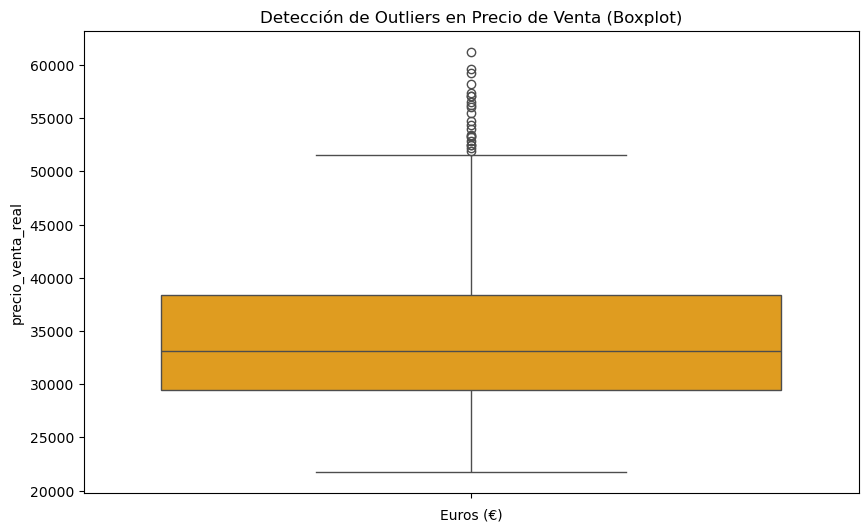

In [30]:
#Analisis de outlier en precio de venta
plt.figure(figsize=(10,6))
sns.boxplot(df_ventas_vehiculo['precio_venta_real'], color='orange')
plt.title('Detección de Outliers en Precio de Venta (Boxplot)')
plt.xlabel('Euros (€)')
plt.show()

Podemos observar que hay precios que superar el valor máximo no atípico. Pero ¿que tipo de vehículos son estos?

In [31]:
# Cálculo numérico del IQR
Q1 = df_ventas_vehiculo['precio_venta_real'].quantile(0.25)
Q3 = df_ventas_vehiculo['precio_venta_real'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR


#Los outliers son:
outliers = df_ventas_vehiculo[df_ventas_vehiculo['precio_venta_real'] > limite_superior]
print("Número de outliers detectados:", outliers.shape[0])
#Mostar marcas y modelos de los outliers
print(outliers[['marca', 'modelo', 'precio_venta_real','segmento']])

Número de outliers detectados: 22
        marca     modelo  precio_venta_real  segmento
28    Renault    Austral              56050       SUV
39        BMW         X1              59659       SUV
40        BMW         X1              61242       SUV
45   Mercedes    Clase E              52516     Sedán
58       Ford       Kuga              54014       SUV
59       Ford       Kuga              53224       SUV
60       Ford       Kuga              58232       SUV
116       Kia       Niro              52883       SUV
117       Kia       Niro              56512       SUV
170   Hyundai      Ionic              53428       SUV
197   Renault  Renault 5              54735     Sedán
206       BMW         X3              56198     Sedán
208    Toyota      Yaris              52191  Compacto
213       Kia       Ceed              55497     Sedán
304       BMW    Serie 3              51911       SUV
358      Ford     Mondeo              52505       SUV
363   Hyundai        i30              54373  Com

Podemos comprobar que se corresponden a vehículos de gama alta, por lo que estos valores no son errores, sino precios legítimos. Eliminarlos sesgaría el modelo, impidiéndole predecir correctamente vehículos de gama alta.

In [32]:
#Validación de cilindrada
cilindrada_cero = df_ventas_vehiculo[df_ventas_vehiculo['cilindrada'] == 0]
print("Número de vehículos con cilindrada cero:", cilindrada_cero.shape[0])


Número de vehículos con cilindrada cero: 93


Hemos podido comprobar que hay vehículos con cilindrada cero, de modo que tenemos que comprobar que todos los vehículos con esta cilindrada sean electricos (puesto que son los únicos que no tienen cilindros) en caso de que haya otro tipo se trataría de un error.

In [33]:
print(cilindrada_cero['combustible'].unique()) # Debería salir solo 'Eléctrico'

['Eléctrico']


Tan solo son coches eléctricos por lo que no hay valores incorrectos

In [34]:
#Validación del consumo medio
consumo_cero_urbano = df_ventas_vehiculo[(df_ventas_vehiculo['consumo_urbano'] <= 0) | (df_ventas_vehiculo['consumo_urbano'] > 20)]
print("Número de vehículos con consumo urbano no realista:", consumo_cero_urbano.shape[0])

consumo_cero_carr = df_ventas_vehiculo[(df_ventas_vehiculo['consumo_extraurbano'] <= 0) | (df_ventas_vehiculo['consumo_extraurbano'] > 20)]
print("Número de vehículos con consumo extraurbano no realista:", consumo_cero_carr.shape[0])

Número de vehículos con consumo urbano no realista: 0
Número de vehículos con consumo extraurbano no realista: 0


No hemos encontrado valores negativos ni consumos imposibles (0 L/100km en coches de combustión o > 20 L/100km) sino que no pasan los consumos más altos de 9 L/100km.

In [35]:
#Comprobación de valores missing en puntuaciones

#Unir dataframes de ventas y opiniones
df_completo = pd.merge(df_ventas_vehiculo, df_opiniones, on="vehiculo_id", how="left")

#Columnas que queremos comprobar
cols_puntuacion = ['puntuacion_conjunta', 'confort', 'seguridad', 
                   'eficiencia', 'diseno', 'fiabilidad']

#Comprobar valores missing
n_ventas_total = len(df_completo)
n_sin_review = df_completo['puntuacion_conjunta'].isnull().sum()
porcentaje_missing = (n_sin_review / n_ventas_total) * 100

print(f"Total de ventas registradas: {n_ventas_total}")
print(f"Ventas sin ninguna opinión de cliente: {n_sin_review}")
print(f"Porcentaje de datos faltantes en puntuaciones: {porcentaje_missing:.2f}%")

#Ver  coche vendidio sin review
print("\nEjemplo de vehículos vendidos sin feedback (Valores Missing):")
missing_reviews = df_completo[df_completo['puntuacion_conjunta'].isnull()]
print(missing_reviews[['vehiculo_id', 'marca', 'modelo', 'puntuacion_conjunta','confort','seguridad','eficiencia','diseno','fiabilidad']].head())

Total de ventas registradas: 1123
Ventas sin ninguna opinión de cliente: 111
Porcentaje de datos faltantes en puntuaciones: 9.88%

Ejemplo de vehículos vendidos sin feedback (Valores Missing):
   vehiculo_id marca modelo  puntuacion_conjunta  confort  seguridad  \
5        VH003   Kia    Ev6                  NaN      NaN        NaN   
6        VH004  Ford   Puma                  NaN      NaN        NaN   
17       VH008  Ford   Puma                  NaN      NaN        NaN   
18       VH008  Ford   Puma                  NaN      NaN        NaN   
19       VH009  Ford   Kuga                  NaN      NaN        NaN   

    eficiencia  diseno  fiabilidad  
5          NaN     NaN         NaN  
6          NaN     NaN         NaN  
17         NaN     NaN         NaN  
18         NaN     NaN         NaN  
19         NaN     NaN         NaN  


Al analizar el fichero origen de opiniones (Opiniones-clientes.xml), no se encontraron valores nulos; sin embargo, al cruzar los datos con las ventas, existen vehículos que no poseen reseñas.

Dado que las opiniones se integrarán dinámicamente en fases posteriores, no se imputarán valores artificiales (como la media) en esta fase para no introducir "ruido".

In [36]:
#Normalización de variables técnicas
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
variables_tecnicas = ['cilindrada', 'potencia_cv']
for var in variables_tecnicas:
    df_ventas_vehiculo[[var + "_normalizado"]] = scaler.fit_transform(df_ventas_vehiculo[[var]])

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,antiguedad,cilindrada_normalizado,potencia_cv_normalizado
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,147,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,147,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,147,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,219,2000,4.1,4.1,149,36500,Sedán,8,0.909091,0.524390
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,130,2200,5.7,4.3,107,34800,Deportivo,6,1.000000,0.162602


Para evitar que variables con escalas grandes (como cilindrada: 1200-2200) dominen sobre variables pequeñas (como consumo: 4-8) en algoritmos basados en distancia (como K-Nearest Neighbors o SVM), se ha aplicado una normalización Min-Max. Si no normalizo, la cilindrada (2000) pesaría mucho más que la potencia (150) simplemente por ser un número más grande, falseando el resultado.

#### - Ingeniería de características

Creación de variables

In [37]:
#Creación de la variable antigüedad
ANIO_ACTUAL = 2026 #Asumo el año actual como 2026

df_ventas_vehiculo['antiguedad'] = ANIO_ACTUAL - df_ventas_vehiculo['anio_fabricacion']

df_ventas_vehiculo.head()


,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,antiguedad,cilindrada_normalizado,potencia_cv_normalizado
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,147,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,147,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,147,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,219,2000,4.1,4.1,149,36500,Sedán,8,0.909091,0.524390
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,130,2200,5.7,4.3,107,34800,Deportivo,6,1.000000,0.162602


In [38]:
#Creación de variable eficiencia global
df_ventas_vehiculo['eficiencia_global'] = (df_ventas_vehiculo['consumo_urbano'] + df_ventas_vehiculo['consumo_extraurbano']) / 2

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,antiguedad,cilindrada_normalizado,potencia_cv_normalizado,eficiencia_global
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,1400,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,2000,4.1,4.1,149,36500,Sedán,8,0.909091,0.524390,4.1
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,2200,5.7,4.3,107,34800,Deportivo,6,1.000000,0.162602,5.0


In [39]:
#Creación de variable ratio precio/potencia
df_ventas_vehiculo['ratio_precio_potencia'] = df_ventas_vehiculo['precio_base'] / df_ventas_vehiculo['potencia_cv']

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,antiguedad,cilindrada_normalizado,potencia_cv_normalizado,eficiencia_global,ratio_precio_potencia
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2,235.374150
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2,235.374150
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,6.9,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2,235.374150
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,4.1,4.1,149,36500,Sedán,8,0.909091,0.524390,4.1,166.666667
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,5.7,4.3,107,34800,Deportivo,6,1.000000,0.162602,5.0,267.692308


In [40]:
#Variable de categoria de emisiones
def clasificador_emisiones(co2):
    if co2 < 110: return 'Eco'
    elif co2 <= 150: return 'Media'
    else: return 'Contaminante'

df_ventas_vehiculo['categoria_emisiones'] = df_ventas_vehiculo['emisiones_co2'].apply(clasificador_emisiones)

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,consumo_extraurbano,emisiones_co2,precio_base,segmento,antiguedad,cilindrada_normalizado,potencia_cv_normalizado,eficiencia_global,ratio_precio_potencia,categoria_emisiones
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2,235.374150,Media
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2,235.374150,Media
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,5.5,149,34600,Compacto,8,0.636364,0.231707,6.2,235.374150,Media
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,4.1,149,36500,Sedán,8,0.909091,0.524390,4.1,166.666667,Media
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,4.3,107,34800,Deportivo,6,1.000000,0.162602,5.0,267.692308,Eco


In [41]:
#Índice de fiabilidad

#Sacar media de fiabilidad por vehiculo id

fiabilidad_media = df_opiniones.groupby('vehiculo_id')['fiabilidad'].mean().reset_index()
fiabilidad_media.rename(columns={'fiabilidad': 'fiabilidad_media'}, inplace=True)

#Unir dataframes principal con fiabilidad media
df = pd.merge(df_ventas_vehiculo, fiabilidad_media, on='vehiculo_id', how='left')

#Tratar valores de coches sin opiniones
media_fiabilidad = df['fiabilidad_media'].mean()
df['fiabilidad_media'].fillna(media_fiabilidad, inplace=True)

#Calcular el índice de fiabilidad: normalizando incidencias y fiabilidad

max_incidencias = df['incidencias_mecanicas'].max()
incidencias_norm = 1 - (df['incidencias_mecanicas'] / max_incidencias)  # Invertido para que menos incidencias sea mejor

fiabilidad_norm = df['fiabilidad_media'] / 5

df['indice_fiabilidad'] = (incidencias_norm + fiabilidad_norm) / 2

df.head()

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\2846861209.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fiabilidad_media'].fillna(media_fiabilidad, inplace=True)


,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,precio_base,segmento,antiguedad,cilindrada_normalizado,potencia_cv_normalizado,eficiencia_global,ratio_precio_potencia,categoria_emisiones,fiabilidad_media,indice_fiabilidad
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,34600,Compacto,8,0.636364,0.231707,6.2,235.374150,Media,4.500000,0.950000
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,34600,Compacto,8,0.636364,0.231707,6.2,235.374150,Media,4.500000,0.950000
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,34600,Compacto,8,0.636364,0.231707,6.2,235.374150,Media,4.500000,0.950000
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,36500,Sedán,8,0.909091,0.524390,4.1,166.666667,Media,3.600000,0.860000
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,34800,Deportivo,6,1.000000,0.162602,5.0,267.692308,Eco,3.640443,0.364044


Análisis de correlación y eliminación

In [42]:
#Tratamiento de variables no numéricas

#Descomposicion temporal

df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])
df['anio_venta'] = df['fecha_venta'].dt.year
df['mes_venta'] = df['fecha_venta'].dt.month

df_corr = df.copy()

#Tratamiento geográfico y combustible
cols_dummies = ['region_vendedor', 'combustible']
df_corr = pd.get_dummies(df_corr, columns=cols_dummies, prefix=['region', 'fuel'], dtype=int)

#Codificacion binaria para la transmision
df_corr['transmision_encoded'] = df_corr['transmision'].map({'Manual': 0, 'Automática': 1})

#Codificación del segmento
mapa_segmento = {'Compacto': 1, 'Sedán': 2, 'SUV': 3, 'Executive': 4, 'Deportivo': 5}
df_corr['segmento_encoded'] = df_corr['segmento'].map(mapa_segmento)

#Codificación del emisiones
df_corr['emisiones_encoded'] = df_corr['categoria_emisiones'].map({'Eco':0, 'Media':1, 'Contaminante':2})


df_corr.head()

,venta_id,vehiculo_id,fecha_venta,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,marca,...,region_Madrid,region_País Vasco,region_Valencia,fuel_Diésel,fuel_Eléctrico,fuel_Gasolina,fuel_Híbrido,transmision_encoded,segmento_encoded,emisiones_encoded
0,VT001,VH001,2023-03-01,34536,168,0,992,0,12937,Peugeot,...,0,0,0,0,0,0,1,0,1,1
1,VT002,VH001,2023-01-24,31929,9835,1,992,0,6894,Peugeot,...,0,1,0,0,0,0,1,0,1,1
2,VT003,VH001,2023-10-11,30964,16270,3,992,0,10366,Peugeot,...,0,1,0,0,0,0,1,0,1,1
3,VT004,VH002,2023-10-20,31897,44127,0,1030,0,6739,Hyundai,...,0,0,0,0,0,1,0,0,2,1
4,VT005,VH003,2023-08-27,34964,20361,2,896,3,18098,Kia,...,0,0,0,0,0,0,1,0,5,0


IMPORTANTE: A la hora de hacer el one hot enconding no se ha eliminado una de la columnas generadas (lo que provocaría colinealidad a la hora de aplicar los modelos), para ver mejor la matriz de correlación y poder asi ver por ejemplo si una region tiene precios de coche más elevados o si un tipo de coches es más caro que el otro. Esto a la hora de aplicar los modelos será necesario quitar una de las columnas si la caracteristica se tiene en cuenta para el modelo.

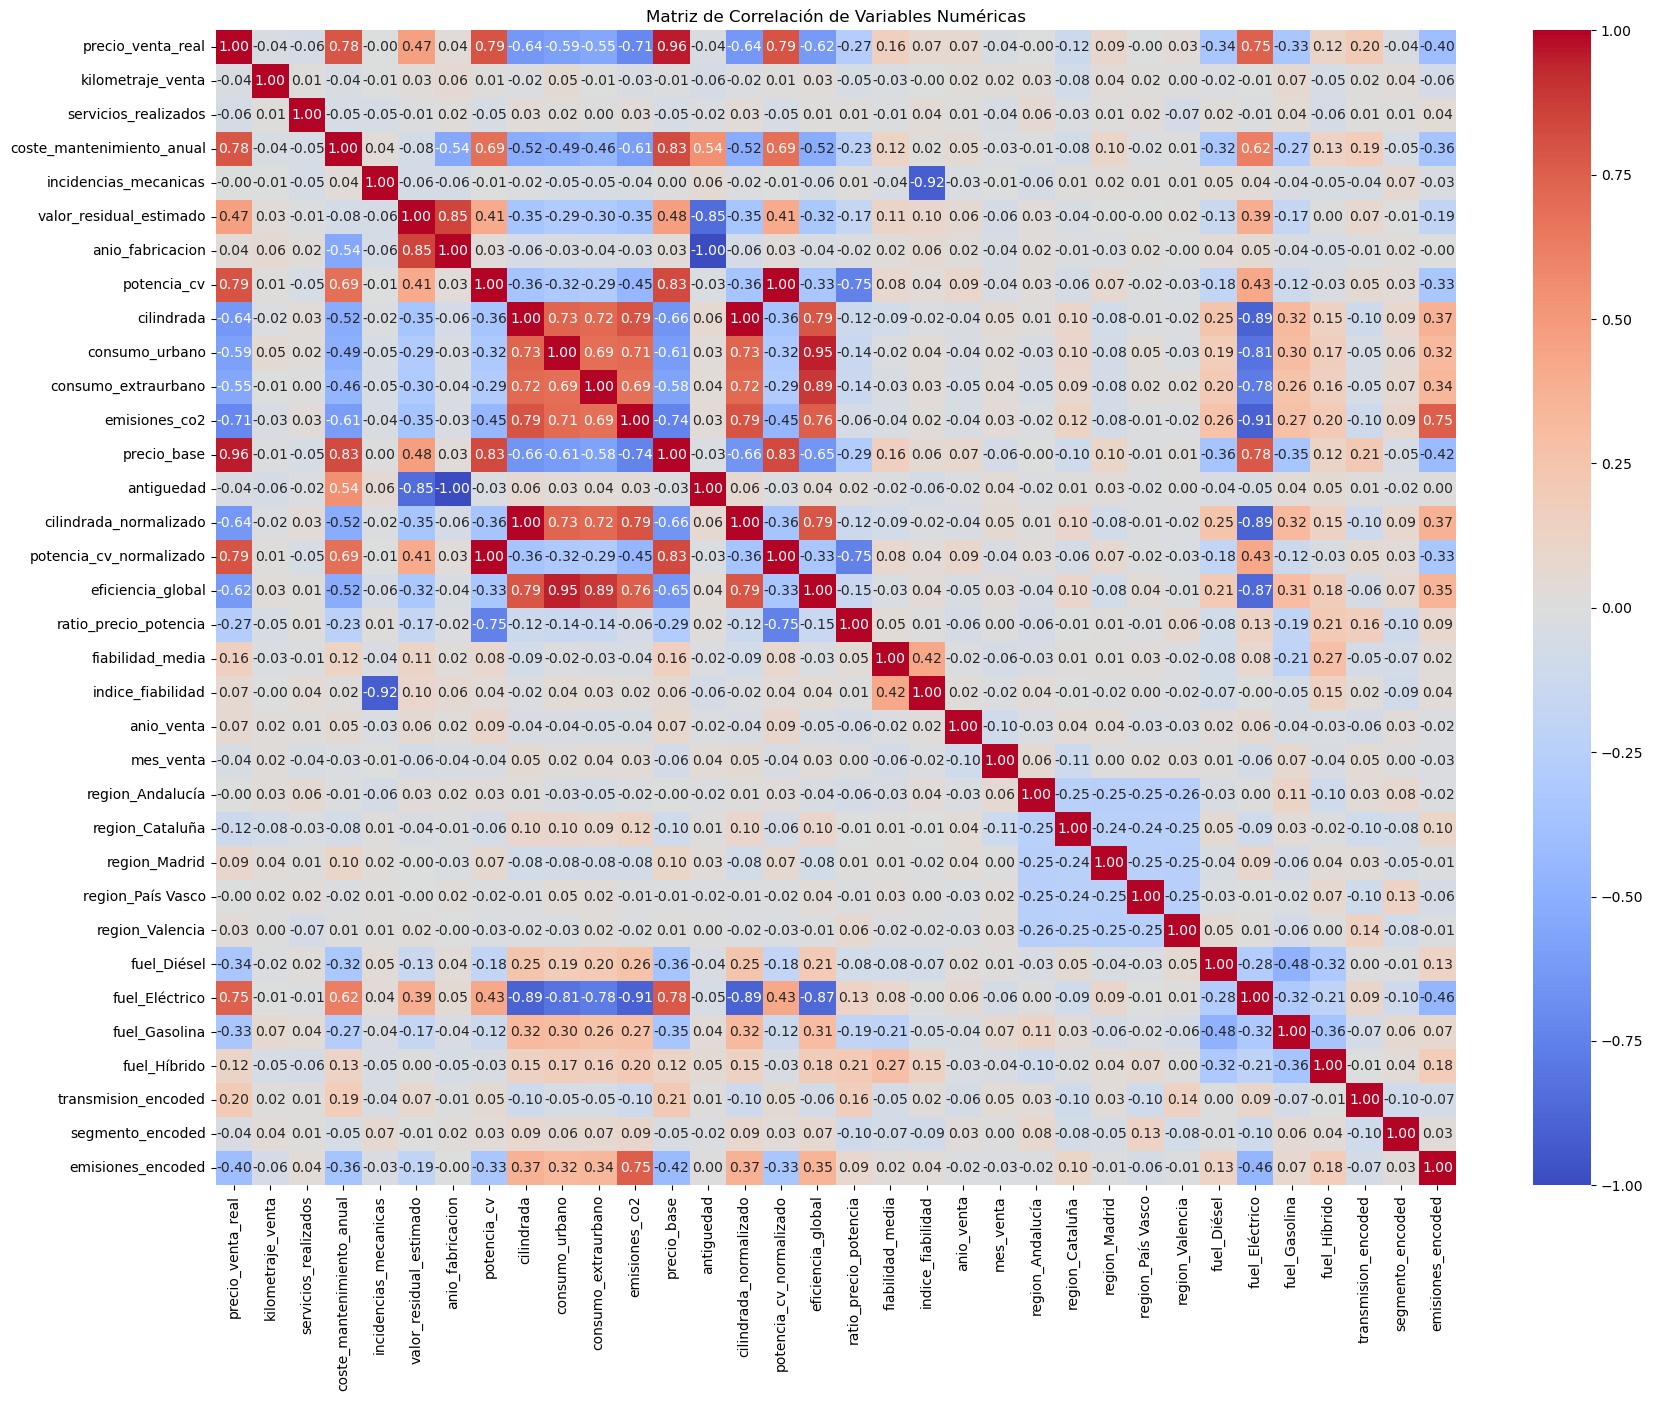

In [43]:
#Matriz de correlación del dataframe de ventas y vehiculos
cols_ignore = ['venta_id', 'vehiculo_id', 'fecha_venta', 'marca', 'modelo', 'transmision', 'categoria_emisiones', 'segmento', 'recomendacion']

#Eliminamos las columnas no numéricas o irrelevantes
df_matrix = df_corr.drop(columns=cols_ignore, errors='ignore').select_dtypes(include=[np.number])

plt.figure(figsize=(20,15))
sns.heatmap(df_matrix.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmax=1, vmin=-1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [44]:
cols_drop_final = [
    'consumo_urbano',       # Redundante con eficiencia_global
    'consumo_extraurbano',  # Redundante con eficiencia_global
    'anio_fabricacion',     # Redundante con antiguedad
    'fecha_venta',          # Sustituida por mes_venta y anio_venta
    'fiabilidad_media'            # Sustituida por indice_fiabilidad
]

df_final_ventas_vehiculo = df_corr.drop(columns=cols_drop_final, errors='ignore')

In [45]:
df_final_ventas_vehiculo.head()

,venta_id,vehiculo_id,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,marca,modelo,...,region_Madrid,region_País Vasco,region_Valencia,fuel_Diésel,fuel_Eléctrico,fuel_Gasolina,fuel_Híbrido,transmision_encoded,segmento_encoded,emisiones_encoded
0,VT001,VH001,34536,168,0,992,0,12937,Peugeot,208,...,0,0,0,0,0,0,1,0,1,1
1,VT002,VH001,31929,9835,1,992,0,6894,Peugeot,208,...,0,1,0,0,0,0,1,0,1,1
2,VT003,VH001,30964,16270,3,992,0,10366,Peugeot,208,...,0,1,0,0,0,0,1,0,1,1
3,VT004,VH002,31897,44127,0,1030,0,6739,Hyundai,i20,...,0,0,0,0,0,1,0,0,2,1
4,VT005,VH003,34964,20361,2,896,3,18098,Kia,Ev6,...,0,0,0,0,0,0,1,0,5,0


In [46]:
#Dataframes con los que trabajaremos en la parte de modelado
df_modelado_ventas = df_final_ventas_vehiculo.copy()
df_modelado_opiniones = df_opiniones.copy()

### Fase 4: Minería de Datos (KDD)

#### - Cuestiones iniciales

¿Qué características determinan el precio?

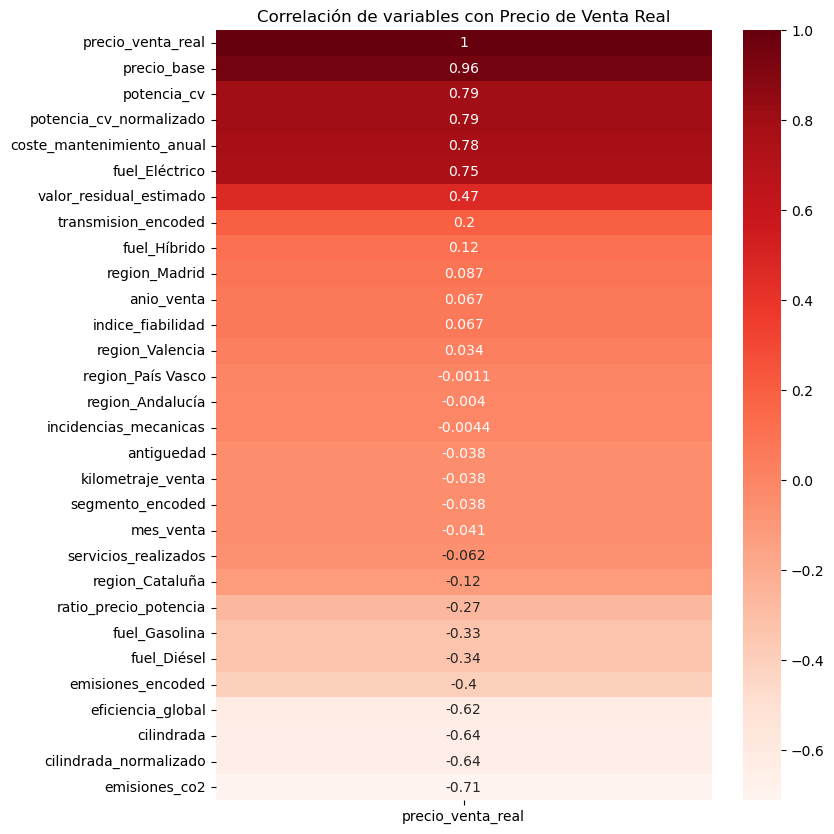

In [47]:
df_ventas= df_modelado_ventas.copy()
cols_ignore = ['venta_id', 'vehiculo_id', 'fecha_venta', 'marca', 'modelo', 'transmision', 'categoria_emisiones', 'segmento', 'recomendacion']

#Eliminamos las columnas no numéricas o irrelevantes
df_ventas = df_ventas.drop(columns=cols_ignore, errors='ignore').select_dtypes(include=[np.number])
#Matriz de correlacion para el precio de venta real
plt.figure(figsize=(8,10))
sns.heatmap(df_ventas.corr()[['precio_venta_real']].sort_values(by='precio_venta_real', ascending=False), annot=True, cmap='Reds')
plt.title('Correlación de variables con Precio de Venta Real')
plt.show()

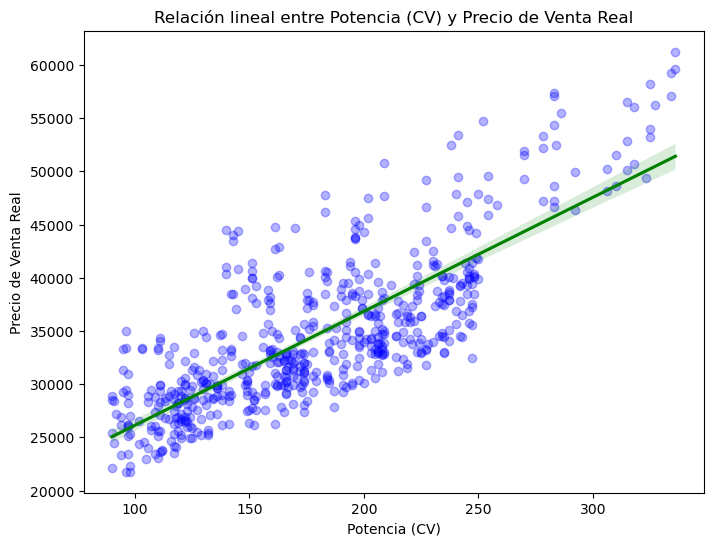

In [48]:
#Relación lineal entre potencia y precio de venta
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='potencia_cv', y='precio_venta_real', 
            ax=plt.gca(), scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'green'})
plt.title('Relación lineal entre Potencia (CV) y Precio de Venta Real')
plt.xlabel('Potencia (CV)')
plt.ylabel('Precio de Venta Real')
plt.show()

Text(0, 0.5, 'Precio de Venta Real')

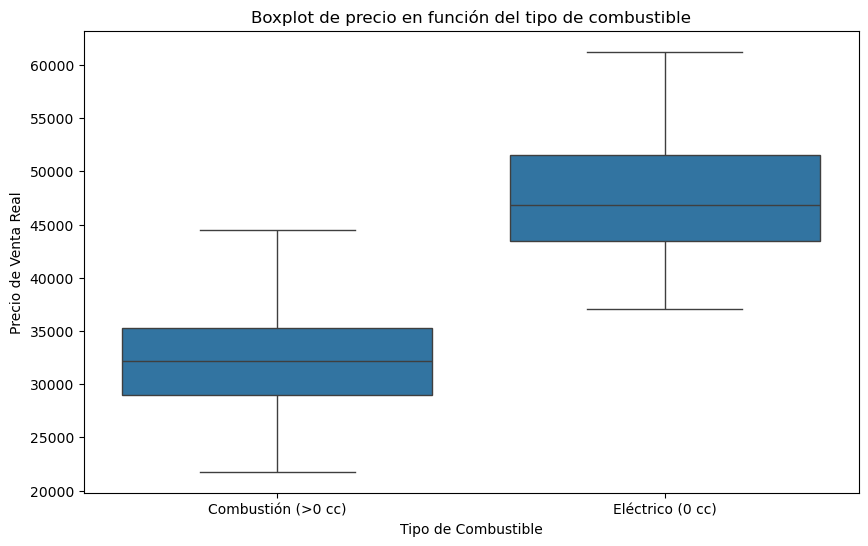

In [49]:
#Boxplot de precio en funcion del tipo de combustible
df_ventas['tecnologia'] = np.where(df_ventas['cilindrada'] == 0, 'Eléctrico (0 cc)', 'Combustión (>0 cc)')
plt.figure(figsize=(10,6))
sns.boxplot(data=df_ventas, x='tecnologia', y='precio_venta_real')
plt.title('Boxplot de precio en función del tipo de combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Precio de Venta Real')

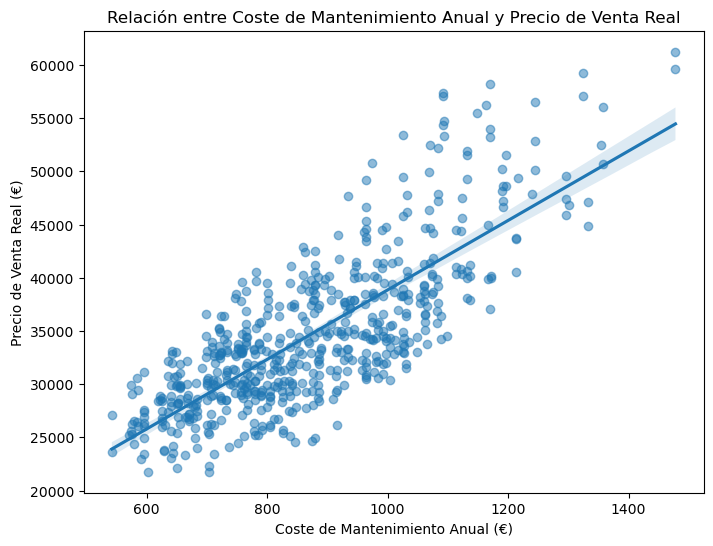

In [50]:
#Relacion entre el coste de mantenimiento anual y el precio de venta real
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='coste_mantenimiento_anual', y='precio_venta_real', scatter_kws={'alpha':0.5})
plt.title('Relación entre Coste de Mantenimiento Anual y Precio de Venta Real')
plt.xlabel('Coste de Mantenimiento Anual (€)')
plt.ylabel('Precio de Venta Real (€)')
plt.show()

¿Podemos segmentar vehículos por perfil de uso y eficiencia?

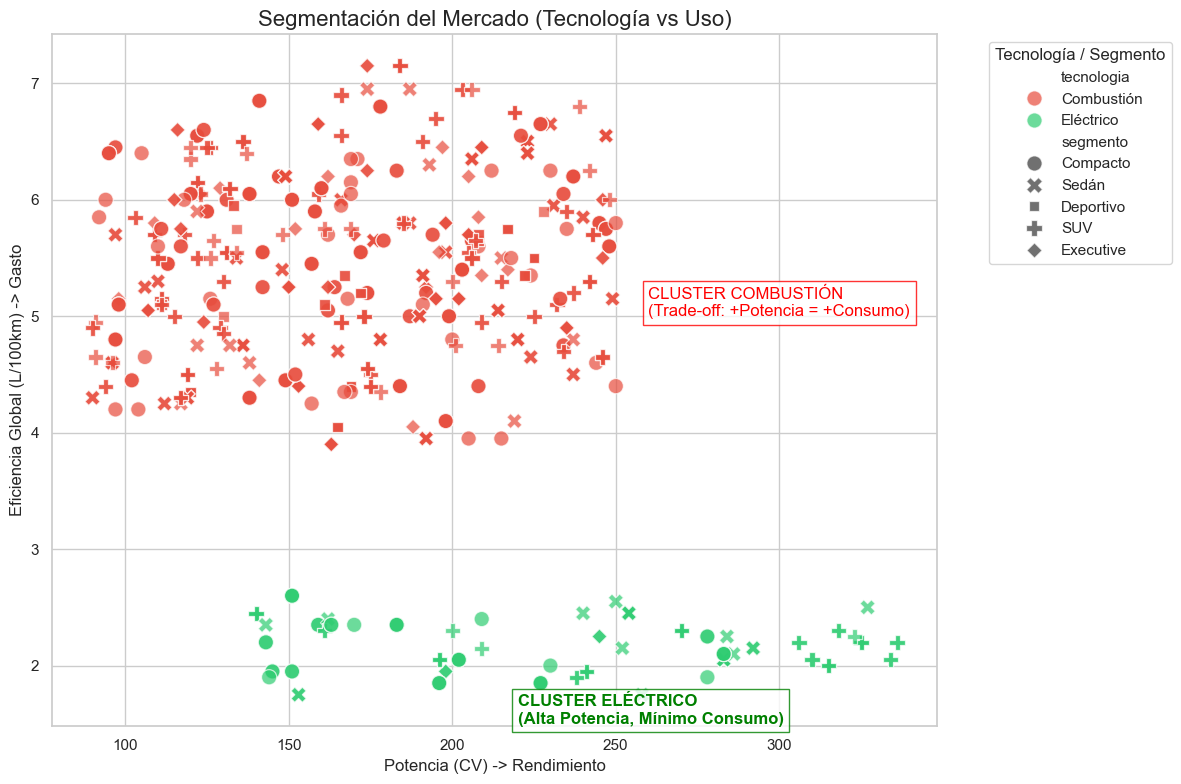

--- Medias por Tecnología ---
            potencia_cv  eficiencia_global
tecnologia                                
Combustión   169.522682           5.474162
Eléctrico    232.505376           2.159140


In [51]:
df_segmento = df_modelado_ventas.copy()

# Creamos la variable de tecnología para colorear
df_segmento['tecnologia'] = np.where(df_segmento['cilindrada'] == 0, 'Eléctrico', 'Combustión')

# Configuración
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Scatter Plot Principal
sns.scatterplot(data=df_segmento, x='potencia_cv', y='eficiencia_global', 
                hue='tecnologia',  # Coloreamos por la verdadera grieta del mercado
                style='segmento',  # Usamos formas para ver si los segmentos se agrupan
                palette={'Eléctrico':'#2ecc71', 'Combustión':'#e74c3c'}, # Verde vs Rojo
                s=120, alpha=0.7)

# Añadimos anotaciones para explicar el gráfico
plt.title("Segmentación del Mercado (Tecnología vs Uso)", fontsize=16)
plt.xlabel("Potencia (CV) -> Rendimiento")
plt.ylabel("Eficiencia Global (L/100km) -> Gasto")

# Dibujamos una flecha o caja para destacar el grupo eléctrico
plt.text(220, 1.5, "CLUSTER ELÉCTRICO\n(Alta Potencia, Mínimo Consumo)", 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='green'), color='green', fontweight='bold')

plt.text(260, 5, "CLUSTER COMBUSTIÓN\n(Trade-off: +Potencia = +Consumo)", 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'), color='red')

plt.legend(title="Tecnología / Segmento", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Datos de apoyo
print("--- Medias por Tecnología ---")
print(df_segmento.groupby('tecnologia')[['potencia_cv', 'eficiencia_global']].mean())

¿Qué factores predicen los costes de mantenimiento?

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\2306183988.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_coste, x='tecnologia', y='coste_mantenimiento_anual',
C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\2306183988.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_coste, x='antiguedad', y='coste_mantenimiento_anual',


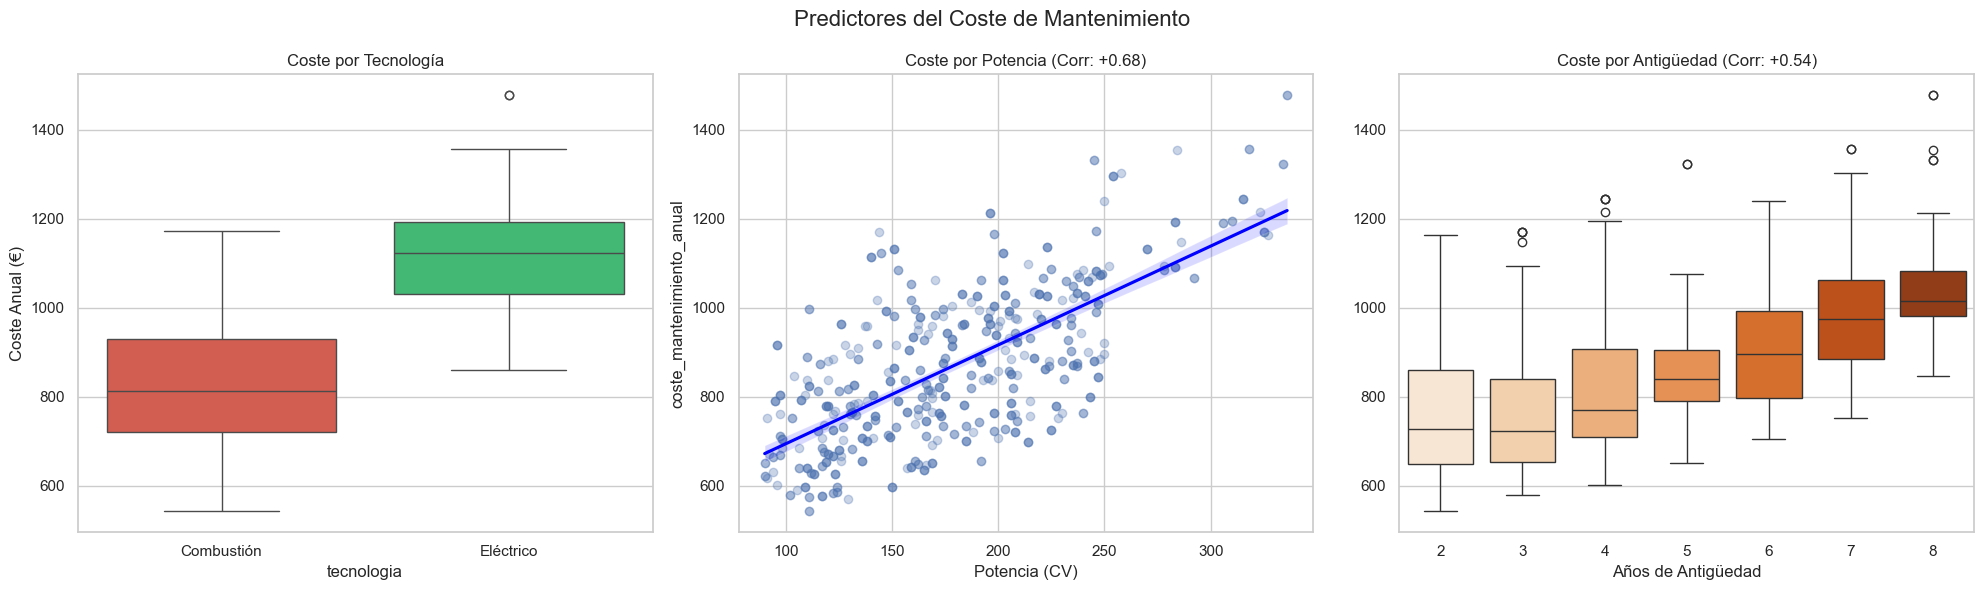

Coste Medio Mantenimiento Eléctrico: nan €
Coste Medio Mantenimiento Combustión: nan €


In [52]:
df_coste = df_modelado_ventas.copy()

# Creamos variable tecnología
df_coste['tecnologia'] = np.where(df_coste['cilindrada'] == 0, 'Eléctrico', 'Combustión')

# Configuración
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#TECNOLOGÍA (Eléctrico vs Combustión)
sns.boxplot(data=df_coste, x='tecnologia', y='coste_mantenimiento_anual', 
            palette={'Eléctrico':'#2ecc71', 'Combustión':'#e74c3c'}, ax=axes[0])
axes[0].set_title("Coste por Tecnología")
axes[0].set_ylabel("Coste Anual (€)")

#POTENCIA (Gama)
sns.regplot(data=df_coste, x='potencia_cv', y='coste_mantenimiento_anual', 
            ax=axes[1], scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
axes[1].set_title("Coste por Potencia (Corr: +0.68)")
axes[1].set_xlabel("Potencia (CV)")

#ANTIGÜEDAD (Desgaste)
sns.boxplot(data=df_coste, x='antiguedad', y='coste_mantenimiento_anual', 
            palette="Oranges", ax=axes[2])
axes[2].set_title("Coste por Antigüedad (Corr: +0.54)")
axes[2].set_xlabel("Años de Antigüedad")
axes[2].set_ylabel("")

plt.suptitle("Predictores del Coste de Mantenimiento", fontsize=16)
plt.tight_layout()
plt.show()

# Datos para el texto
media_elec = df_ventas[df_ventas['tecnologia']=='Eléctrico']['coste_mantenimiento_anual'].mean()
media_comb = df_ventas[df_ventas['tecnologia']=='Combustión']['coste_mantenimiento_anual'].mean()
print(f"Coste Medio Mantenimiento Eléctrico: {media_elec:.2f} €")
print(f"Coste Medio Mantenimiento Combustión: {media_comb:.2f} €")

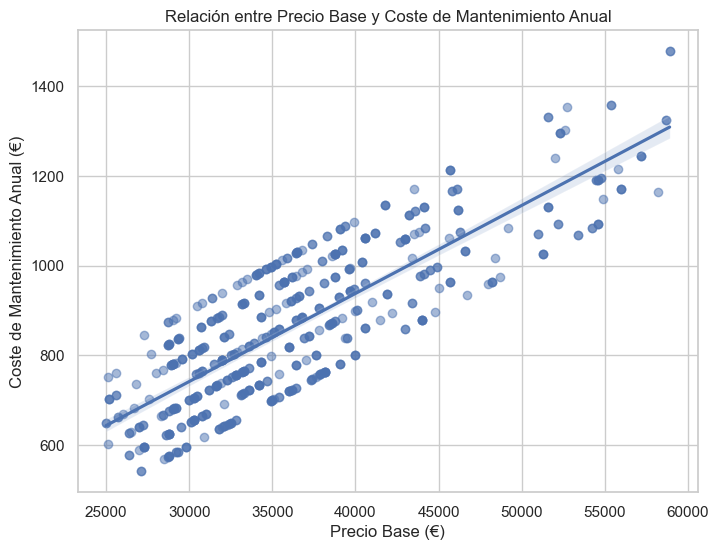

In [53]:
#Relación entre el precio base y el coste de mantenimiento anual
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='precio_base', y='coste_mantenimiento_anual', scatter_kws={'alpha':0.5})
plt.title('Relación entre Precio Base y Coste de Mantenimiento Anual')
plt.xlabel('Precio Base (€)')
plt.ylabel('Coste de Mantenimiento Anual (€)')
plt.show()

¿Existen patrones en las ventas por temporada y región?

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\4080962258.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_temp, x='region_vendedor', y='precio_venta_real', order=region_order, palette="Blues_r", ax=axes[0])


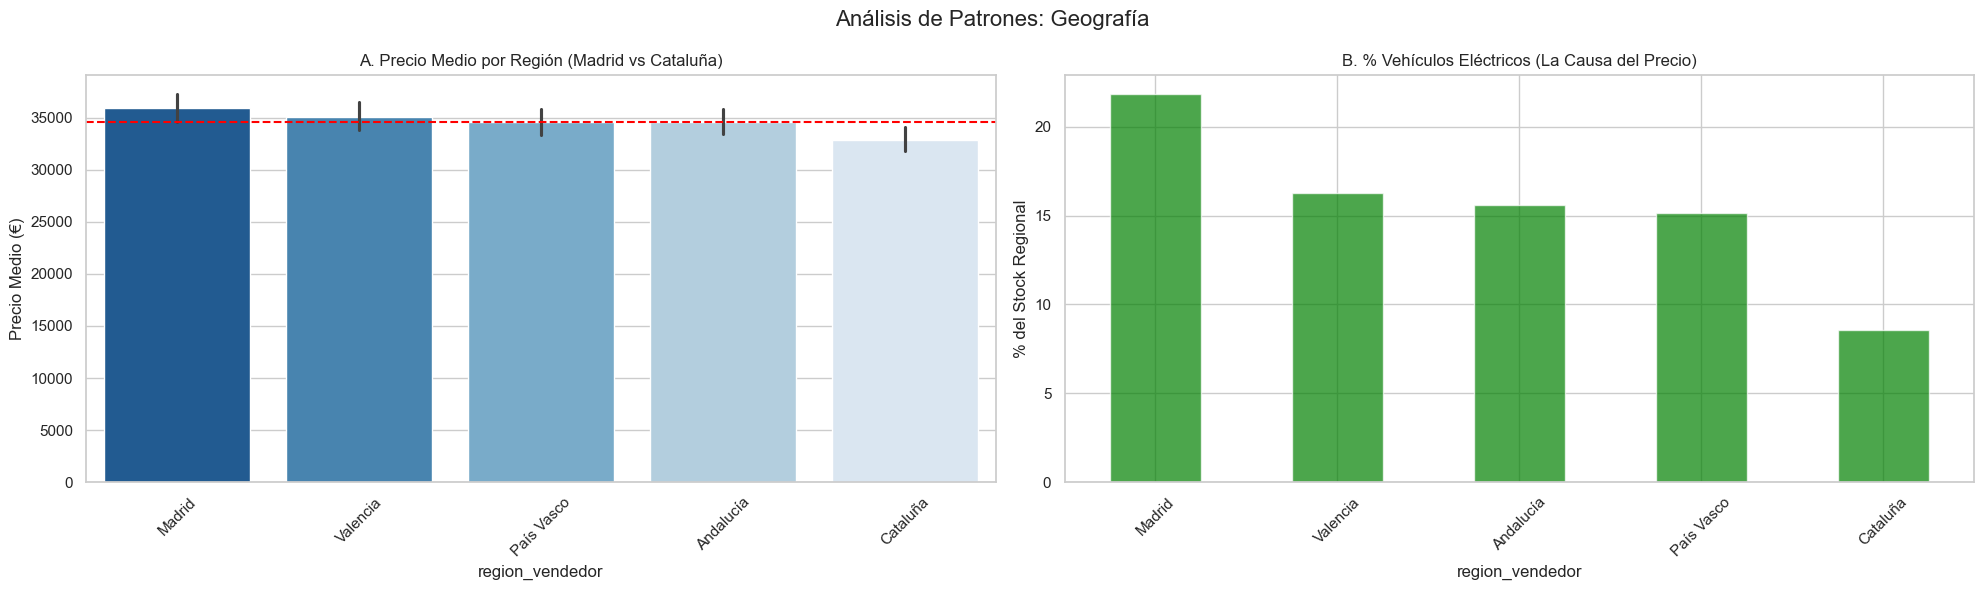

Precio Medio Madrid: 35892 €
Precio Medio Cataluña: 32898 €


C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\4080962258.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_temp, x='mes_venta', palette="cool")


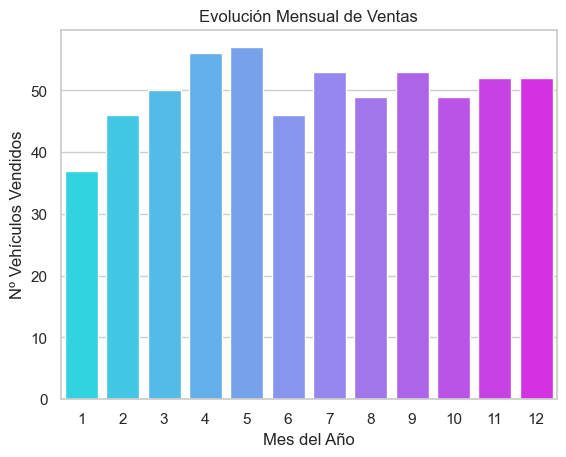

In [54]:
df_temp = df_modelado_ventas.copy()
#Reconstruir Región
cols_region = [c for c in df_temp.columns if c.startswith('region_')]
if cols_region:
    df_temp['region_vendedor'] = df_temp[cols_region].idxmax(axis=1).apply(lambda x: x.replace('region_', ''))

#Crear variables explicativas (Eléctrico/Premium)
df_temp['is_electric'] = (df_temp['cilindrada'] == 0)

# Configuración del Panel
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

#Precio medio por región
region_order = df_temp.groupby('region_vendedor')['precio_venta_real'].mean().sort_values(ascending=False).index
sns.barplot(data=df_temp, x='region_vendedor', y='precio_venta_real', order=region_order, palette="Blues_r", ax=axes[0])
axes[0].set_title("A. Precio Medio por Región (Madrid vs Cataluña)")
axes[0].set_ylabel("Precio Medio (€)")
axes[0].tick_params(axis='x', rotation=45)
# Añadimos línea de media nacional
axes[0].axhline(df_temp['precio_venta_real'].mean(), color='red', linestyle='--', label='Media Nacional')

# Calculamos el % de eléctricos por región
elec_pct = df_temp.groupby('region_vendedor')['is_electric'].mean().sort_values(ascending=False) * 100
elec_pct.plot(kind='bar', ax=axes[1], color='green', alpha=0.7)
axes[1].set_title("B. % Vehículos Eléctricos (La Causa del Precio)")
axes[1].set_ylabel("% del Stock Regional")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Análisis de Patrones: Geografía", fontsize=16)
plt.tight_layout()
plt.show()

# Datos para el texto
print(f"Precio Medio Madrid: {df_temp[df_temp['region_vendedor']=='Madrid']['precio_venta_real'].mean():.0f} €")
print(f"Precio Medio Cataluña: {df_temp[df_temp['region_vendedor']=='Cataluña']['precio_venta_real'].mean():.0f} €")


# ESTACIONALIDAD (Ventas por Mes)
sns.countplot(data=df_temp, x='mes_venta', palette="cool")
plt.title("Evolución Mensual de Ventas")
plt.xlabel("Mes del Año")
plt.ylabel("Nº Vehículos Vendidos")
plt.show()

¿Cómo predecir el valor residual de un vehículo?

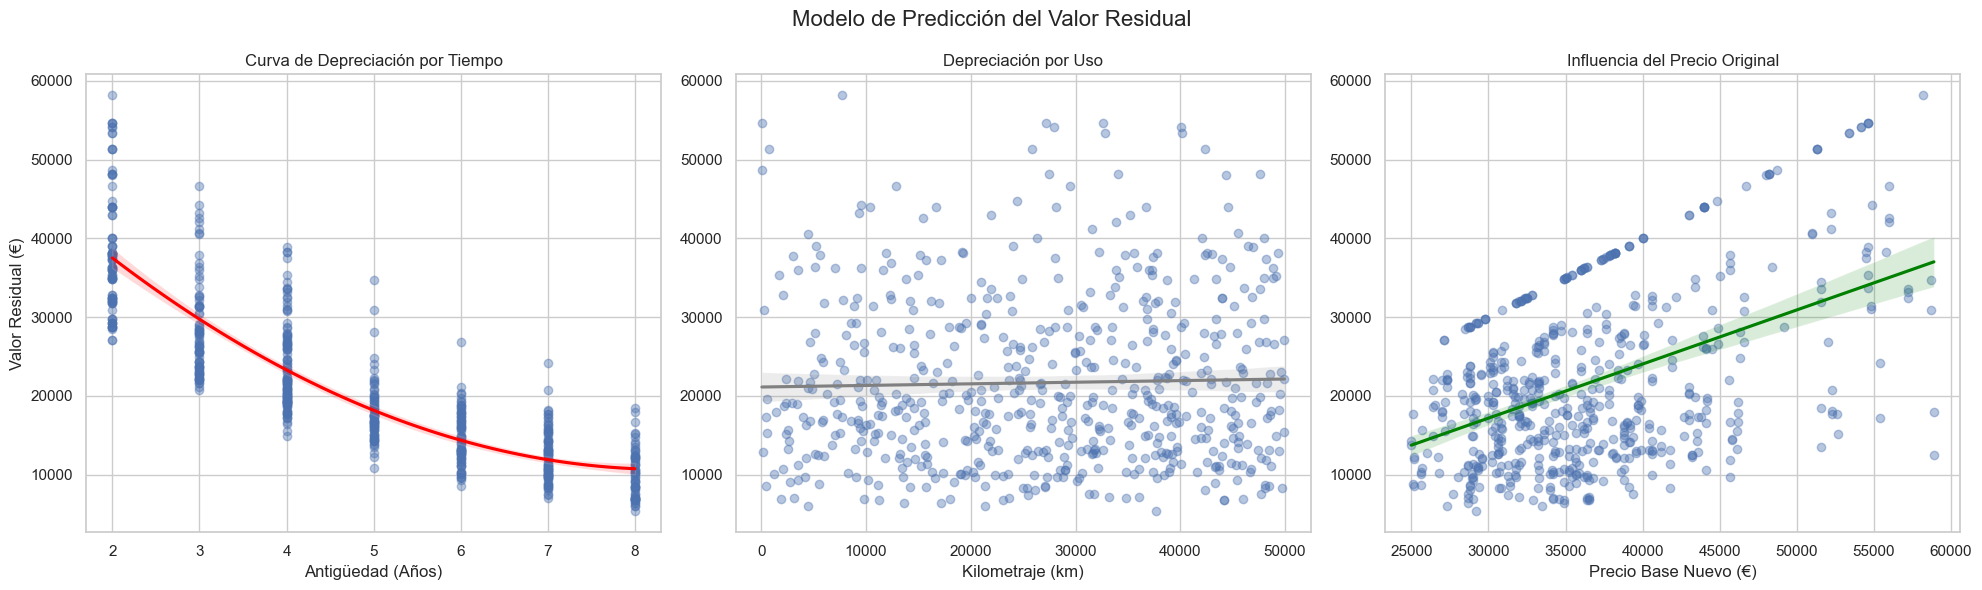

Correlación Antigüedad vs Valor Residual: -0.85
Correlación Km vs Valor Residual: 0.03


In [55]:
df_valor = df_modelado_ventas.copy()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# GRÁFICO 1: ANTIGÜEDAD
# Usamos order=2 para ajustar una curva polinómica (parábola) y ver la caída no lineal
sns.regplot(data=df_valor, x='antiguedad', y='valor_residual_estimado', 
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'}, order=2, ax=axes[0])
axes[0].set_title("Curva de Depreciación por Tiempo")
axes[0].set_xlabel("Antigüedad (Años)")
axes[0].set_ylabel("Valor Residual (€)")

# GRÁFICO 2: KILOMETRAJE
sns.regplot(data=df_valor, x='kilometraje_venta', y='valor_residual_estimado', 
            scatter_kws={'alpha':0.4}, line_kws={'color':'gray'}, ax=axes[1])
axes[1].set_title("Depreciación por Uso")
axes[1].set_xlabel("Kilometraje (km)")
axes[1].set_ylabel("")

# GRÁFICO 3: PRECIO BASE
sns.regplot(data=df_valor, x='precio_base', y='valor_residual_estimado', 
            scatter_kws={'alpha':0.4}, line_kws={'color':'green'}, ax=axes[2])
axes[2].set_title("Influencia del Precio Original")
axes[2].set_xlabel("Precio Base Nuevo (€)")
axes[2].set_ylabel("")

plt.suptitle("Modelo de Predicción del Valor Residual", fontsize=16)
plt.tight_layout()
plt.show()

# Imprimir correlaciones para el texto
print(f"Correlación Antigüedad vs Valor Residual: {df_valor['antiguedad'].corr(df_valor['valor_residual_estimado']):.2f}")
print(f"Correlación Km vs Valor Residual: {df_valor['kilometraje_venta'].corr(df_valor['valor_residual_estimado']):.2f}")

### 4.1  Árboles de Decisión para prededir valor residual

In [56]:
# Copias de los datasets originales
df_modelado_ventas_tree = df_modelado_ventas.copy()
df_modelado_opiniones_tree = df_modelado_opiniones.copy()

# Agregación de opiniones por vehiculo_id
#    - Media para puntuaciones
#    - Moda para recomendación
opiniones_agg = df_modelado_opiniones_tree.groupby('vehiculo_id').agg({
    'puntuacion_conjunta': 'mean',
    'recomendacion': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
}).reset_index()


# Left join con el dataset de ventas
df_modelo_tree = df_modelado_ventas_tree.merge(
    opiniones_agg,
    on='vehiculo_id',
    how='left'
)

df_modelo_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   venta_id                   600 non-null    object 
 1   vehiculo_id                600 non-null    object 
 2   precio_venta_real          600 non-null    int64  
 3   kilometraje_venta          600 non-null    int64  
 4   servicios_realizados       600 non-null    int64  
 5   coste_mantenimiento_anual  600 non-null    int64  
 6   incidencias_mecanicas      600 non-null    int64  
 7   valor_residual_estimado    600 non-null    int64  
 8   marca                      600 non-null    object 
 9   modelo                     600 non-null    object 
 10  transmision                600 non-null    object 
 11  potencia_cv                600 non-null    int64  
 12  cilindrada                 600 non-null    int64  
 13  emisiones_co2              600 non-null    int64  

In [57]:
# Creación de la variable objetivo
#    Categorizamos el valor residual en 3 grupos
df_modelo_tree['valor_residual_categoria'] = pd.qcut(
    df_modelo_tree['valor_residual_estimado'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
)

In [58]:
# Selección de variables
features = [
    # Configuración del vehículo
    'transmision_encoded',
    'fuel_Diésel',
    'fuel_Gasolina',
    'fuel_Híbrido',
    'fuel_Eléctrico',

    # Características técnicas
    'potencia_cv',
    'eficiencia_global',

    # Uso
    'antiguedad',
    'kilometraje_venta',

    # Mantenimiento
    'coste_mantenimiento_anual',
    'incidencias_mecanicas',

    # Opiniones
    'puntuacion_conjunta',
    'recomendacion'
]

# Se le añade el valor residual
df_modelo_tree = df_modelo_tree[
    features + ['valor_residual_categoria']
]

# Mapeamos la recomendación
df_modelo_tree['recomendacion'] = df_modelo_tree['recomendacion'].map({
    'Si': 1,
    'No': 0
})

# Eliminamos filas con valores faltantes
df_modelo_tree = df_modelo_tree.dropna()

df_modelo_tree

,transmision_encoded,fuel_Diésel,fuel_Gasolina,fuel_Híbrido,fuel_Eléctrico,potencia_cv,eficiencia_global,antiguedad,kilometraje_venta,coste_mantenimiento_anual,incidencias_mecanicas,puntuacion_conjunta,recomendacion,valor_residual_categoria
0,0,0,0,1,0,147,6.2,8,168,992,0,4.30,1.0,Bajo
1,0,0,0,1,0,147,6.2,8,9835,992,0,4.30,1.0,Bajo
2,0,0,0,1,0,147,6.2,8,16270,992,0,4.30,1.0,Bajo
3,0,0,1,0,0,219,4.1,8,44127,1030,0,3.55,0.0,Bajo
6,1,0,1,0,0,237,5.2,4,16064,876,3,4.80,1.0,Alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0,0,0,1,0,175,4.4,3,21468,802,0,4.40,1.0,Alto
596,0,0,0,1,0,175,4.4,3,37381,802,0,4.40,1.0,Alto
597,1,0,1,0,0,235,4.9,4,30305,872,1,3.30,0.0,Alto
598,1,0,1,0,0,235,4.9,4,9781,872,0,3.30,0.0,Alto


In [59]:
# Comprobamos el dataset final
df_modelo_tree.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489 entries, 0 to 599
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   transmision_encoded        489 non-null    int64   
 1   fuel_Diésel                489 non-null    int32   
 2   fuel_Gasolina              489 non-null    int32   
 3   fuel_Híbrido               489 non-null    int32   
 4   fuel_Eléctrico             489 non-null    int32   
 5   potencia_cv                489 non-null    int64   
 6   eficiencia_global          489 non-null    float64 
 7   antiguedad                 489 non-null    int64   
 8   kilometraje_venta          489 non-null    int64   
 9   coste_mantenimiento_anual  489 non-null    int64   
 10  incidencias_mecanicas      489 non-null    int64   
 11  puntuacion_conjunta        489 non-null    float64 
 12  recomendacion              489 non-null    float64 
 13  valor_residual_categoria   489 non-null 

In [60]:
# 7. Separación de variables X e y
X = df_modelo_tree.drop(columns='valor_residual_categoria')
y = df_modelo_tree['valor_residual_categoria']

In [61]:
# 8. Train / Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
# 9. Entrenamiento del Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6, # Limitamos a 6 por el sobreajuste
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,6
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Predicción
y_pred = model.predict(X_test)

# Visualizacion de resultados
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nF1-score (weighted):", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8061224489795918

F1-score (weighted): 0.7978028478472134

Classification report:
               precision    recall  f1-score   support

        Alto       0.84      1.00      0.91        32
        Bajo       0.80      0.82      0.81        34
       Medio       0.76      0.59      0.67        32

    accuracy                           0.81        98
   macro avg       0.80      0.81      0.80        98
weighted avg       0.80      0.81      0.80        98



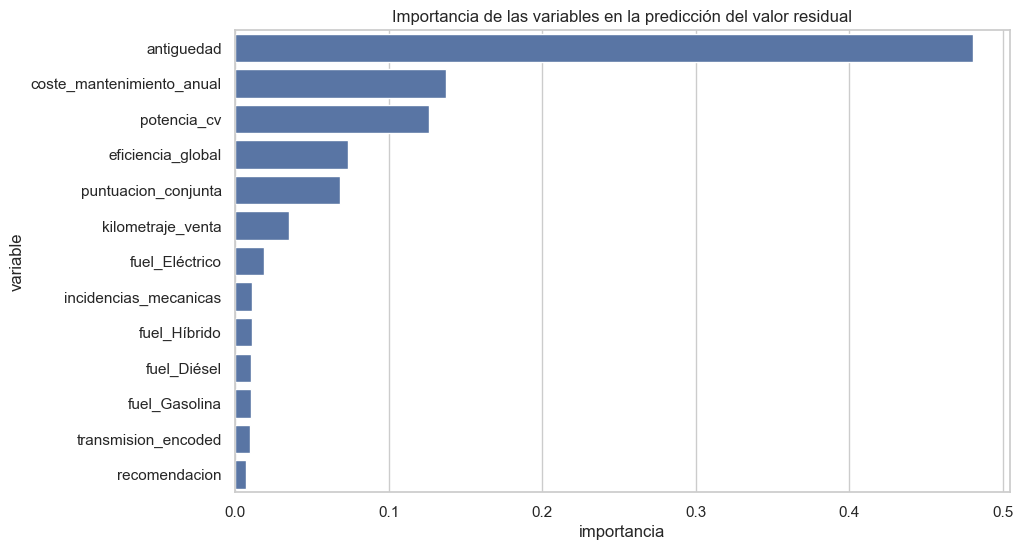

In [64]:
# 11. Importancia de variables
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'variable': X.columns,
    'importancia': importances
}).sort_values(by='importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='importancia',
    y='variable',
    data=feature_importance
)
plt.title('Importancia de las variables en la predicción del valor residual')
plt.show()

Tras realizar el grafico de importancia de variables podemos ver que:
- Antiguedad, coste_mantenimiento y potencia son las caracteristicas mas importantes a la hora de realizar la predicción del valor residual.
- Variables como eficiencia, puntuacion, kilometraje y fuel electrico son influyentes pero en un nivel mas bajo que las anteriones.
- Variables como incidencias, fuel hibrido, fuel diesel, fuel gasolina, transmision y recomendacion practicamente no influyen casi nada el la prediccion.

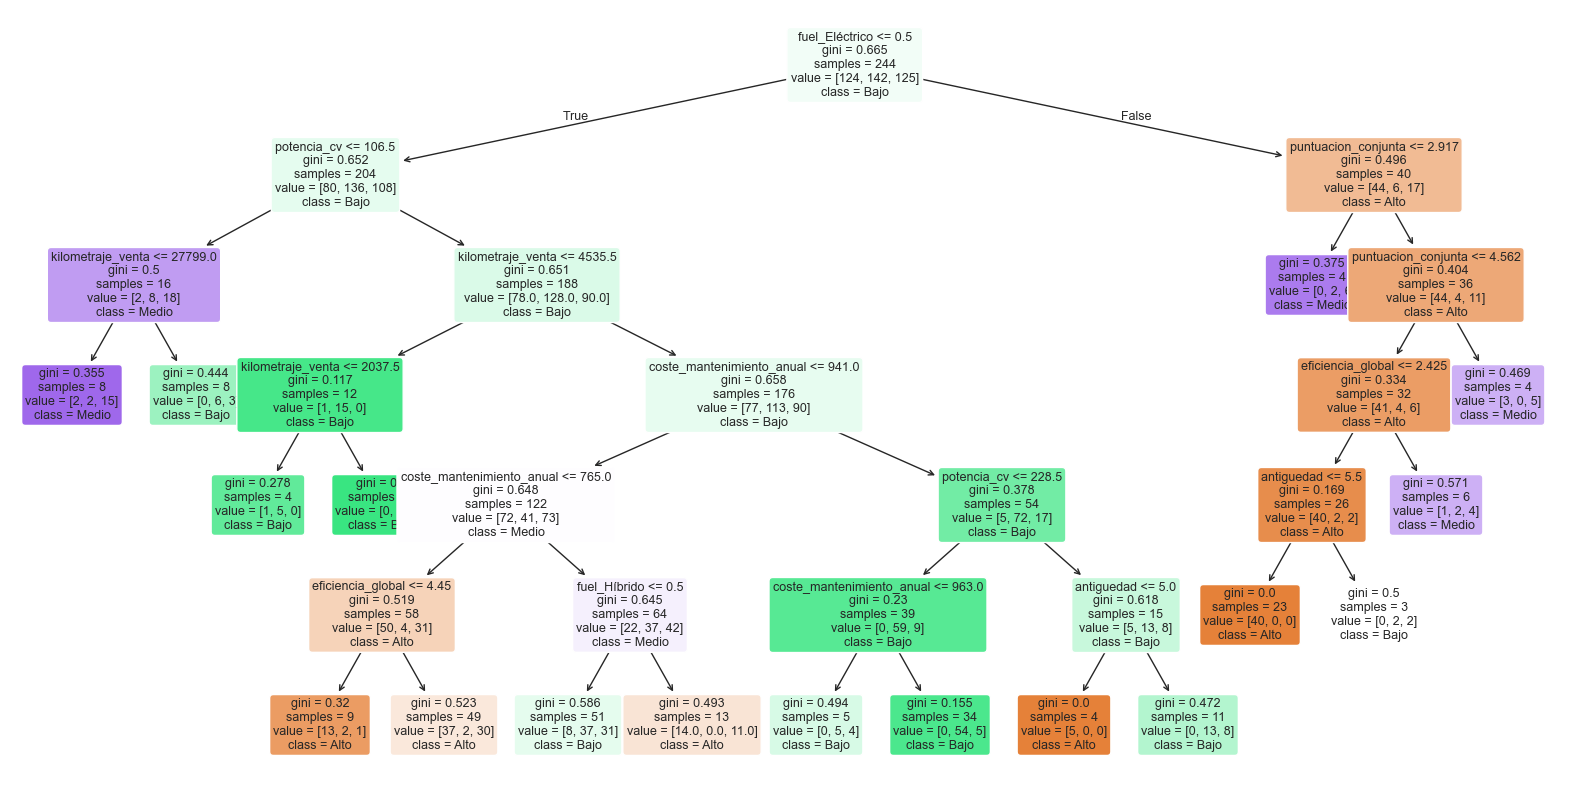

In [65]:
# 12. Visualización de un árbol
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

Las reseñas influyen en algunos segmentos (especialmente eléctricos), pero las características técnicas y de uso siguen siendo los principales determinantes del valor residual.

### 4.2 Regresión Múltiple para Precios

In [66]:
# Copiamos los datasets originales
df_modelado_ventas_tree = df_modelado_ventas.copy()
df_modelado_opiniones_tree = df_opiniones.copy()

In [67]:
# Agregación de reseñas por vehículo
#    - Media para puntuación
#    - Moda para recomendación
opiniones_agg = df_modelado_opiniones_tree.groupby('vehiculo_id').agg({
    'puntuacion_conjunta': 'mean',
    'recomendacion': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
}).reset_index()

In [68]:
# Left join con el dataset de ventas
df_rf_precio = df_modelado_ventas_tree.merge(
    opiniones_agg,
    on='vehiculo_id',
    how='left'
)

In [69]:
# Selección de variables explicativas y objetivo
features_precio = [
    # Configuración del vehículo
    'transmision_encoded',
    'fuel_Diésel',
    'fuel_Gasolina',
    'fuel_Híbrido',
    'fuel_Eléctrico',

    # Características técnicas
    'potencia_cv',
    'eficiencia_global',

    # Uso del vehículo
    'antiguedad',
    'kilometraje_venta',

    # Mantenimiento
    'coste_mantenimiento_anual',
    'incidencias_mecanicas',

    # Reseñas agregadas
    'puntuacion_conjunta',
    'recomendacion'
]

df_rf_precio = df_rf_precio[
    features_precio + ['precio_venta_real']
]

# Mapeamos la recomendación
df_rf_precio['recomendacion'] = df_rf_precio['recomendacion'].map({
    'Si': 1,
    'No': 0
})

# Eliminamos filas con valores nulos
df_rf_precio = df_rf_precio.dropna()

df_rf_precio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489 entries, 0 to 599
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transmision_encoded        489 non-null    int64  
 1   fuel_Diésel                489 non-null    int32  
 2   fuel_Gasolina              489 non-null    int32  
 3   fuel_Híbrido               489 non-null    int32  
 4   fuel_Eléctrico             489 non-null    int32  
 5   potencia_cv                489 non-null    int64  
 6   eficiencia_global          489 non-null    float64
 7   antiguedad                 489 non-null    int64  
 8   kilometraje_venta          489 non-null    int64  
 9   coste_mantenimiento_anual  489 non-null    int64  
 10  incidencias_mecanicas      489 non-null    int64  
 11  puntuacion_conjunta        489 non-null    float64
 12  recomendacion              489 non-null    float64
 13  precio_venta_real          489 non-null    int64  
dtyp

In [70]:
# Definimos X e y
X = df_rf_precio.drop(columns='precio_venta_real')
y = df_rf_precio['precio_venta_real']

In [71]:
# Division Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [72]:
from sklearn.ensemble import RandomForestRegressor

# Entrenamiento del Random Forest Regressor
model_rf_precio = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, # Limitamos a 6 por el sobreajuste
    min_samples_split=10,
    random_state=42
)

model_rf_precio.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,6
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
# Predicción
y_pred = model_rf_precio.predict(X_test)

In [74]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Evaluación del modelo
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

R²: 0.924
RMSE: 2011.01
MAE: 1555.72


In [75]:
# Importancia de variables
importancias = model_rf_precio.feature_importances_

feature_importance_precio = pd.DataFrame({
    'variable': X.columns,
    'importancia': importancias
}).sort_values(by='importancia', ascending=False)

print(feature_importance_precio)

                     variable  importancia
6           eficiencia_global     0.441916
5                 potencia_cv     0.332610
4              fuel_Eléctrico     0.131220
3                fuel_Híbrido     0.037270
9   coste_mantenimiento_anual     0.021294
8           kilometraje_venta     0.011399
11        puntuacion_conjunta     0.011126
0         transmision_encoded     0.006714
7                  antiguedad     0.002549
10      incidencias_mecanicas     0.001983
2               fuel_Gasolina     0.000888
12              recomendacion     0.000657
1                 fuel_Diésel     0.000374


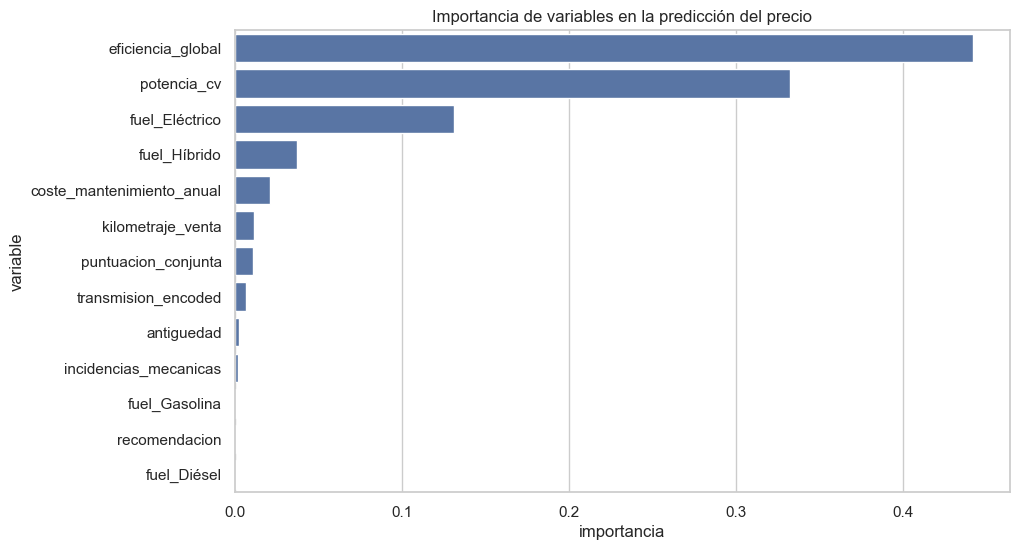

In [76]:
# Gráfica de importancias

plt.figure(figsize=(10,6))
sns.barplot(
    x='importancia',
    y='variable',
    data=feature_importance_precio
)
plt.title('Importancia de variables en la predicción del precio')
plt.show()

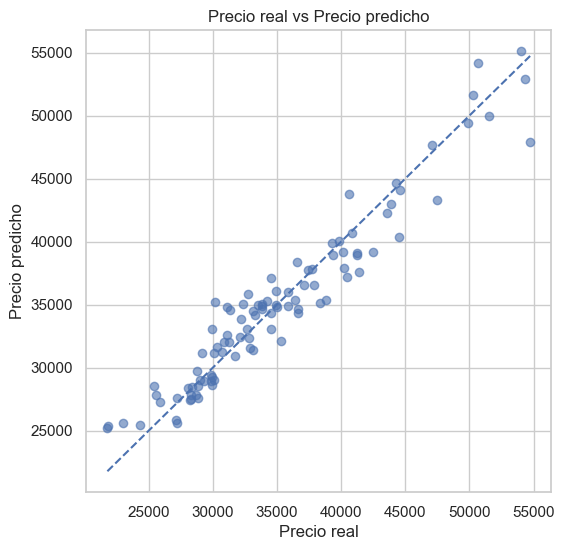

In [77]:
# Precio real vs precio predicho
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Precio real vs Precio predicho')
plt.show()

    ¿Qué características de las reseñas predicen mejor el precio del vehículo?

A partir del modelo de Random Forest Regressor y del análisis de importancia de variables, se observa que:

- La variable puntuacion_conjunta es la única característica procedente de las reseñas que presenta una importancia apreciable en la predicción del precio.

- La variable recomendacion tiene una importancia prácticamente nula, lo que indica que su capacidad explicativa es muy limitada.

Esto sugiere que:

- Las valoraciones medias numéricas capturan mejor la percepción global del vehículo por parte de los usuarios.

- Una recomendación binaria (sí/no) aporta poca información adicional al modelo.

    ¿Son vinculantes las reseñas?
A la vista de los resultados, se puede concluir que las reseñas no son vinculantes en la determinación del precio, aunque sí actúan como un factor complementario.

El modelo alcanza un alto poder de R2 principalmente a:

- características técnicas

- uso del vehículo

- eficiencia energética

Las reseñas:

- mejoran ligeramente el ajuste del modelo

- ayudan a afinar la predicción

Por ello estas reseñas no determinan el precio final de forma directa

#### 4.3. Análisis de Sentimiento en Reviews usando Naive Bayes

In [78]:
#Importaciones para el análisis de sentimiento y naive bayes
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re

In [79]:
#Datos
df_reviews = df_modelado_opiniones.copy()
df_ventas = df_modelado_ventas.copy()

In [80]:
#Primer paso, limpieza básica del texto de las reviews
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()  # Convertir a minúsculas
    texto = re.sub(r'[^\w\s]', '', texto)  # Eliminar puntuación
    return texto

#Creamos una nueva columna con el texto limpio
df_reviews['review_limpia'] = df_reviews['texto_review'].apply(limpiar_texto)

In [81]:
df_reviews.head()

,review_id,vehiculo_id,cliente_id,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad,recomendacion,texto_review,review_limpia
0,RV001,VH204,CUST173,3.4,3.4,3.9,4.8,3.6,3.0,No,"Problemático, poco espacio",problemático poco espacio
1,RV002,VH249,CUST034,3.0,3.1,3.4,4.1,2.9,2.6,No,"Decepcionante, poco espacio",decepcionante poco espacio
2,RV003,VH244,CUST038,5.0,5.0,5.0,5.0,5.0,5.0,Si,"Eficiente vehículo, gran rendimiento",eficiente vehículo gran rendimiento
3,RV004,VH280,CUST022,3.9,3.9,3.9,4.8,3.5,3.1,Si,"Problemático, precio elevado",problemático precio elevado
4,RV005,VH125,CUST153,4.0,4.2,4.5,4.2,4.1,5.0,Si,"Lento, precio elevado",lento precio elevado


In [82]:
#Creamos columna de sentimiento binario (a partir de la recomendación)
df_reviews['sentimiento'] = df_reviews['recomendacion'].apply(lambda x: 1 if x == 'Si' else 0)

df_reviews.head()

,review_id,vehiculo_id,cliente_id,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad,recomendacion,texto_review,review_limpia,sentimiento
0,RV001,VH204,CUST173,3.4,3.4,3.9,4.8,3.6,3.0,No,"Problemático, poco espacio",problemático poco espacio,0
1,RV002,VH249,CUST034,3.0,3.1,3.4,4.1,2.9,2.6,No,"Decepcionante, poco espacio",decepcionante poco espacio,0
2,RV003,VH244,CUST038,5.0,5.0,5.0,5.0,5.0,5.0,Si,"Eficiente vehículo, gran rendimiento",eficiente vehículo gran rendimiento,1
3,RV004,VH280,CUST022,3.9,3.9,3.9,4.8,3.5,3.1,Si,"Problemático, precio elevado",problemático precio elevado,1
4,RV005,VH125,CUST153,4.0,4.2,4.5,4.2,4.1,5.0,Si,"Lento, precio elevado",lento precio elevado,1


El porque se hace el sentimiento a partir de la recomendación es debido a que cuando un cliente marca una opción como si o no, es una decisión final. Sin embargo, puede darle a un coche una puntución de 4 o 5 pero no lo recomiendo porque sea muy caro. (Aunque también puede haber review contradictorias)

Accuracy: 0.8
Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80        40
           1       1.00      0.67      0.80        60

    accuracy                           0.80       100
   macro avg       0.83      0.83      0.80       100
weighted avg       0.87      0.80      0.80       100



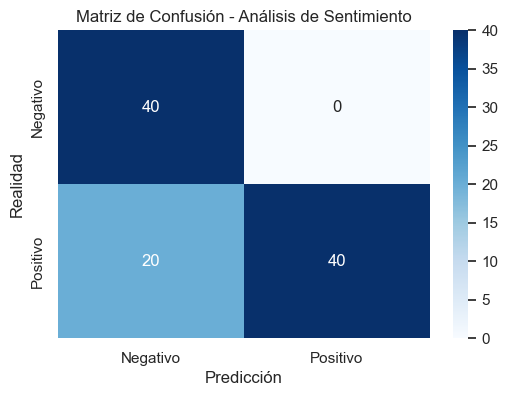

In [83]:
# Vectorización (TF-IDF)
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df_reviews['review_limpia'])
y = df_reviews['sentimiento']

#Division en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Entrenamiento
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)

#Evaluación
y_pred = modelo_nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

#Matriz de confusion visualizada cambiando 0 por negativo y 1 por positivo
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión - Análisis de Sentimiento')
plt.show()

In [84]:
#Cruce de ventas y opiniones

df_merged = pd.merge(df_reviews, df_ventas, on='vehiculo_id', how='inner')
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   review_id                  1012 non-null   object 
 1   vehiculo_id                1012 non-null   object 
 2   cliente_id                 1012 non-null   object 
 3   puntuacion_conjunta        1012 non-null   float64
 4   confort                    1012 non-null   float64
 5   seguridad                  1012 non-null   float64
 6   eficiencia                 1012 non-null   float64
 7   diseno                     1012 non-null   float64
 8   fiabilidad                 1012 non-null   float64
 9   recomendacion              1012 non-null   object 
 10  texto_review               1012 non-null   object 
 11  review_limpia              1012 non-null   object 
 12  sentimiento                1012 non-null   int64  
 13  venta_id                   1012 non-null   objec

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\2465334511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='recomendacion', y='precio_venta_real', palette='Set2')


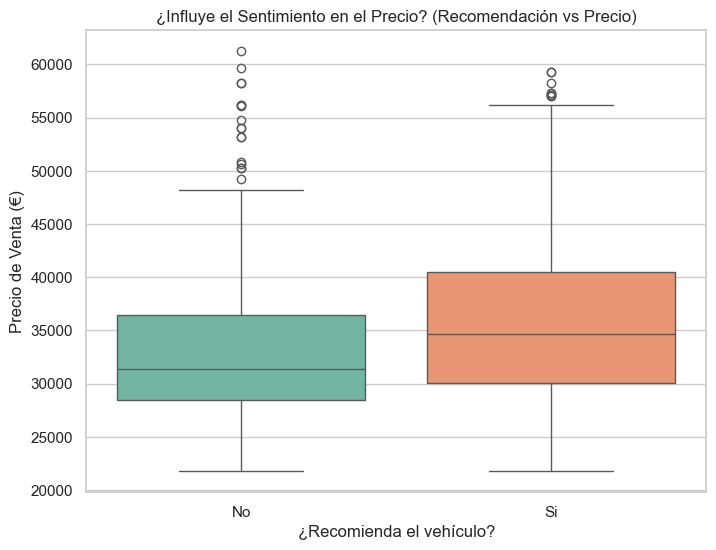

Correlación entre Sentimiento y Precio de Venta: 0.20


In [85]:
# SENTIMIENTO VS PRECIO
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_merged, x='recomendacion', y='precio_venta_real', palette='Set2')
plt.title('¿Influye el Sentimiento en el Precio? (Recomendación vs Precio)')
plt.ylabel('Precio de Venta (€)')
plt.xlabel('¿Recomienda el vehículo?')
plt.show()
#Correlacion entre precio y sentimiento
correlacion_sentimiento_precio = df_merged['sentimiento'].corr(df_merged['precio_venta_real'])
print(f"Correlación entre Sentimiento y Precio de Venta: {correlacion_sentimiento_precio:.2f}")

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\1713385759.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='recomendacion', y='indice_fiabilidad', ax=axes[0], palette='coolwarm')
C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\1713385759.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='recomendacion', y='potencia_cv', ax=axes[1], palette='coolwarm')


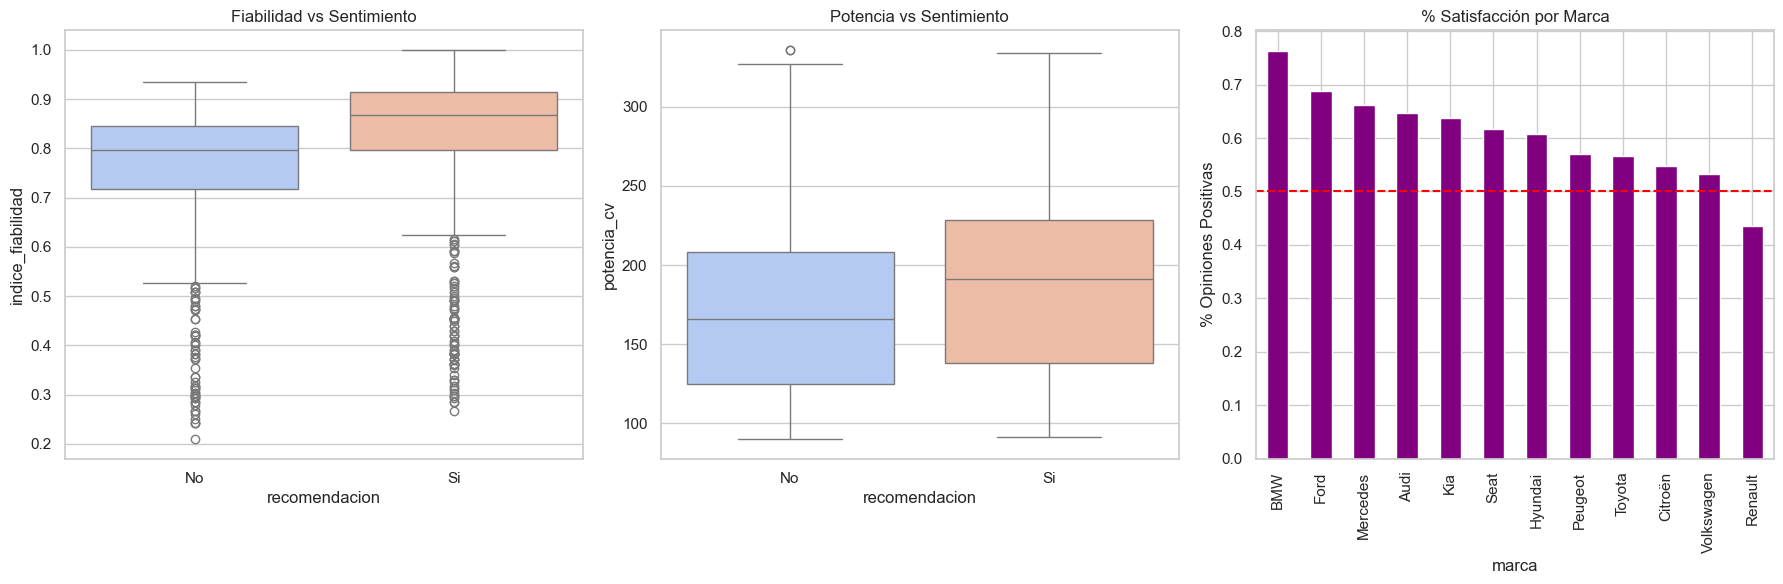

In [86]:
#CARACTERÍSTICAS QUE PREDICEN RESEÑAS POSITIVAS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# A) Fiabilidad
sns.boxplot(data=df_merged, x='recomendacion', y='indice_fiabilidad', ax=axes[0], palette='coolwarm')
axes[0].set_title("Fiabilidad vs Sentimiento")

# B) Potencia
sns.boxplot(data=df_merged, x='recomendacion', y='potencia_cv', ax=axes[1], palette='coolwarm')
axes[1].set_title("Potencia vs Sentimiento")

# C) Marca
# Calculamos % de positivos por marca
brand_satisfaction = df_merged.groupby('marca')['sentimiento'].mean().sort_values(ascending=False)
brand_satisfaction.plot(kind='bar', color='purple', ax=axes[2])
axes[2].set_title("% Satisfacción por Marca")
axes[2].set_ylabel("% Opiniones Positivas")
axes[2].axhline(0.5, color='red', linestyle='--') # Línea de aprobado

plt.tight_layout()
plt.show()

#### 4.4. Utiliza el algoritmo K-nn y SVM para detectar anomalías en los precios

In [87]:
df_anomalias = df_modelado_ventas.copy()

df_anomalias

,venta_id,vehiculo_id,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,marca,modelo,...,region_Madrid,region_País Vasco,region_Valencia,fuel_Diésel,fuel_Eléctrico,fuel_Gasolina,fuel_Híbrido,transmision_encoded,segmento_encoded,emisiones_encoded
0,VT001,VH001,34536,168,0,992,0,12937,Peugeot,208,...,0,0,0,0,0,0,1,0,1,1
1,VT002,VH001,31929,9835,1,992,0,6894,Peugeot,208,...,0,1,0,0,0,0,1,0,1,1
2,VT003,VH001,30964,16270,3,992,0,10366,Peugeot,208,...,0,1,0,0,0,0,1,0,1,1
3,VT004,VH002,31897,44127,0,1030,0,6739,Hyundai,i20,...,0,0,0,0,0,1,0,0,2,1
4,VT005,VH003,34964,20361,2,896,3,18098,Kia,Ev6,...,0,0,0,0,0,0,1,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,VT596,VH299,37130,21468,6,802,0,30401,Citroën,C4,...,0,0,0,0,0,0,1,0,3,2
596,VT597,VH299,38550,37381,1,802,0,28489,Citroën,C4,...,0,1,0,0,0,0,1,0,3,2
597,VT598,VH300,39811,30305,1,872,1,27563,Kia,Picanto,...,0,0,0,0,0,1,0,1,4,0
598,VT599,VH300,37445,9781,0,872,0,26783,Kia,Picanto,...,0,1,0,0,0,1,0,1,4,0


In [88]:
#Aplicación de KNN para detectar anomalías en el precio de venta real

#Caracteristicas relevantes
features = [
    'potencia_cv', 
    'antiguedad', 
    'kilometraje_venta', 
    'eficiencia_global', 
    'coste_mantenimiento_anual',
    'incidencias_mecanicas',
    'servicios_realizados'
]

target = 'precio_venta_real'

X = df_anomalias[features]
y = df_anomalias[target]

#Escalado de características, necesario para KNN
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [89]:
#Aplicación de KNN, buscando vecinos no solo que se parezcan en motor sino también en estado mécanico del vehiculo
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_scaled, y)
#Predicción de precios con KNN
y_pred = knn.predict(X_scaled)

#Cálculo del error absoluto entre el precio real y el predicho
residuo = np.abs(y - y_pred)
umbral = np.percentile(residuo, 95)  # Consideramos anomalías los casos con residuo en el percentil 95 o superior
df_anomalias['anomalia'] = residuo > umbral
#Número de anomalías detectadas
n_anomalias = df_anomalias['anomalia'].sum()
print(f"Número de anomalías detectadas: {n_anomalias}")

Número de anomalías detectadas: 30


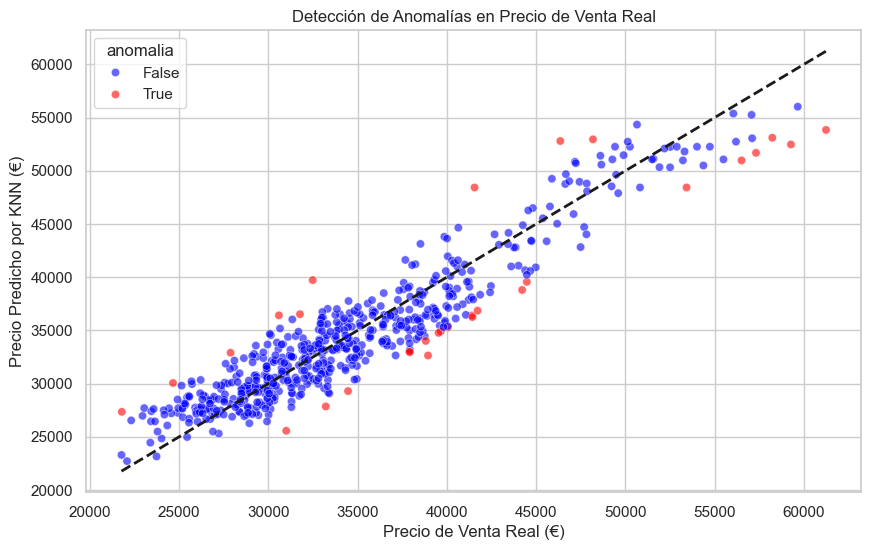

In [90]:
#Visualización de las anomalías
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_anomalias, x='precio_venta_real', y=y_pred, hue='anomalia', palette={False:'blue', True:'red'}, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # Línea de igualdad
plt.title('Detección de Anomalías en Precio de Venta Real')
plt.xlabel('Precio de Venta Real (€)')
plt.ylabel('Precio Predicho por KNN (€)')
plt.show()

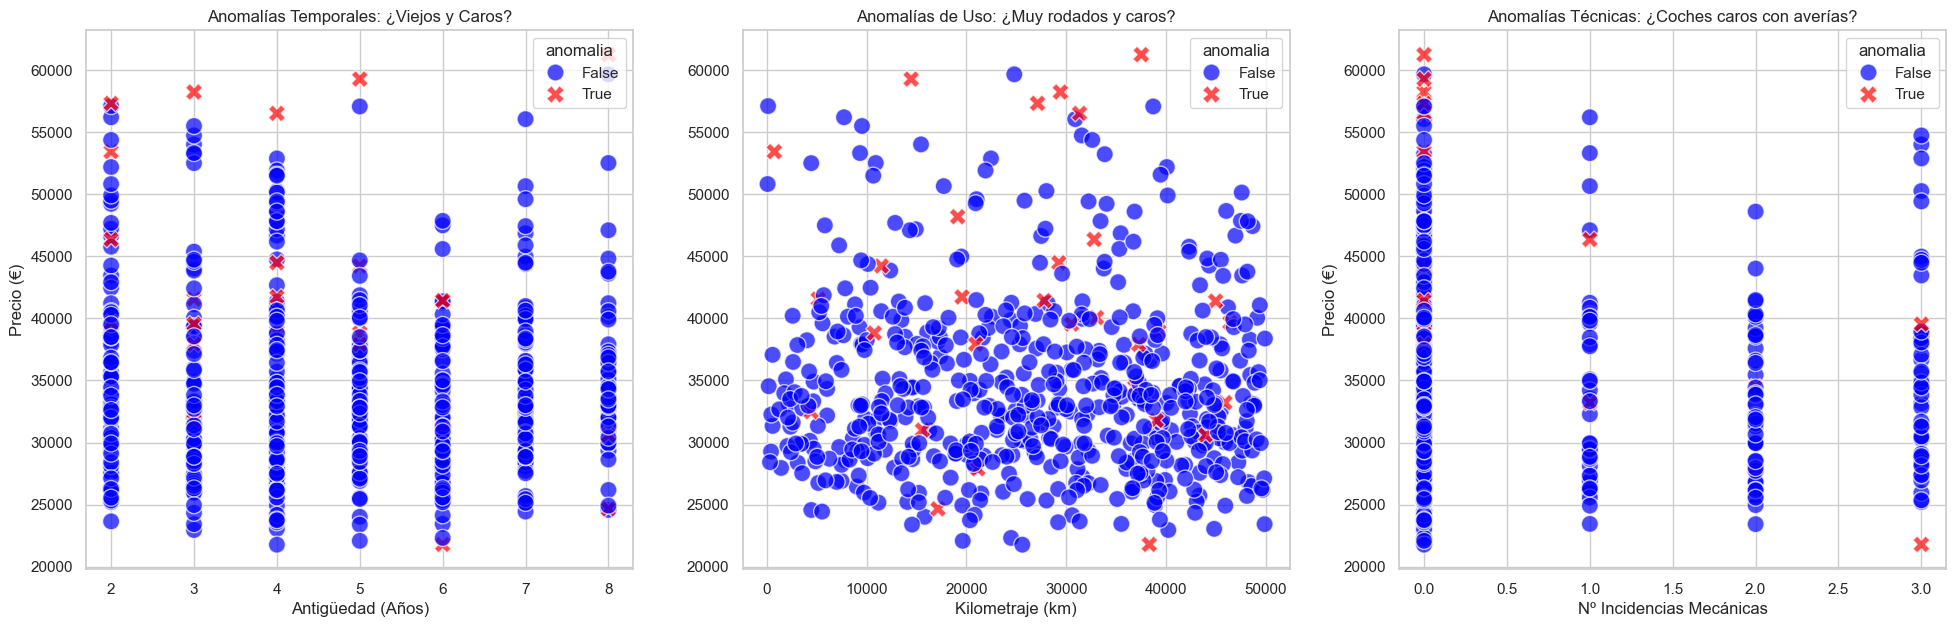

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sns.set_theme(style="whitegrid")

# Configuración de estilo para anomalías
scatter_kws = {'palette': {False: 'blue', True: 'red'}, 'style': 'anomalia', 'markers': {False: 'o', True: 'X'}, 's': 150, 'alpha': 0.7}

# La Dimensión Tiempo (Antigüedad vs Precio)
sns.scatterplot(data=df_anomalias, x='antiguedad', y='precio_venta_real', hue='anomalia', ax=axes[0], **scatter_kws)
axes[0].set_title("Anomalías Temporales: ¿Viejos y Caros?")
axes[0].set_xlabel("Antigüedad (Años)")
axes[0].set_ylabel("Precio (€)")

# La Dimensión Uso (Kilometraje vs Precio)
sns.scatterplot(data=df_anomalias, x='kilometraje_venta', y='precio_venta_real', hue='anomalia', ax=axes[1], **scatter_kws)
axes[1].set_title("Anomalías de Uso: ¿Muy rodados y caros?")
axes[1].set_xlabel("Kilometraje (km)")
axes[1].set_ylabel("")

# La Dimensión Técnica (Incidencias vs Precio)
sns.scatterplot(data=df_anomalias, x='incidencias_mecanicas', y='precio_venta_real', hue='anomalia', ax=axes[2], **scatter_kws)
axes[2].set_title("Anomalías Técnicas: ¿Coches caros con averías?")
axes[2].set_xlabel("Nº Incidencias Mecánicas")
axes[2].set_ylabel("Precio (€)")
plt.show()

In [92]:
#Aplicación de SVM para detectar anomalías en el precio de venta real
from sklearn.svm import SVR
# Usamos C=100 para darle libertad al modelo de ajustarse a los datos, y kernel RBF
svm = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svm.fit(X_scaled, y)
y_pred_svm = svm.predict(X_scaled)

#Cálculo del residuo para SVM
residuo_svm = np.abs(y - y_pred_svm)
umbral_svm = np.percentile(residuo_svm, 95) # Mismo criterio de anomalía
df_anomalias['anomalia_svm'] = residuo_svm > umbral_svm
n_anomalias_svm = df_anomalias['anomalia_svm'].sum()
print(f"Número de anomalías detectadas por SVM: {n_anomalias_svm}")

Número de anomalías detectadas por SVM: 30


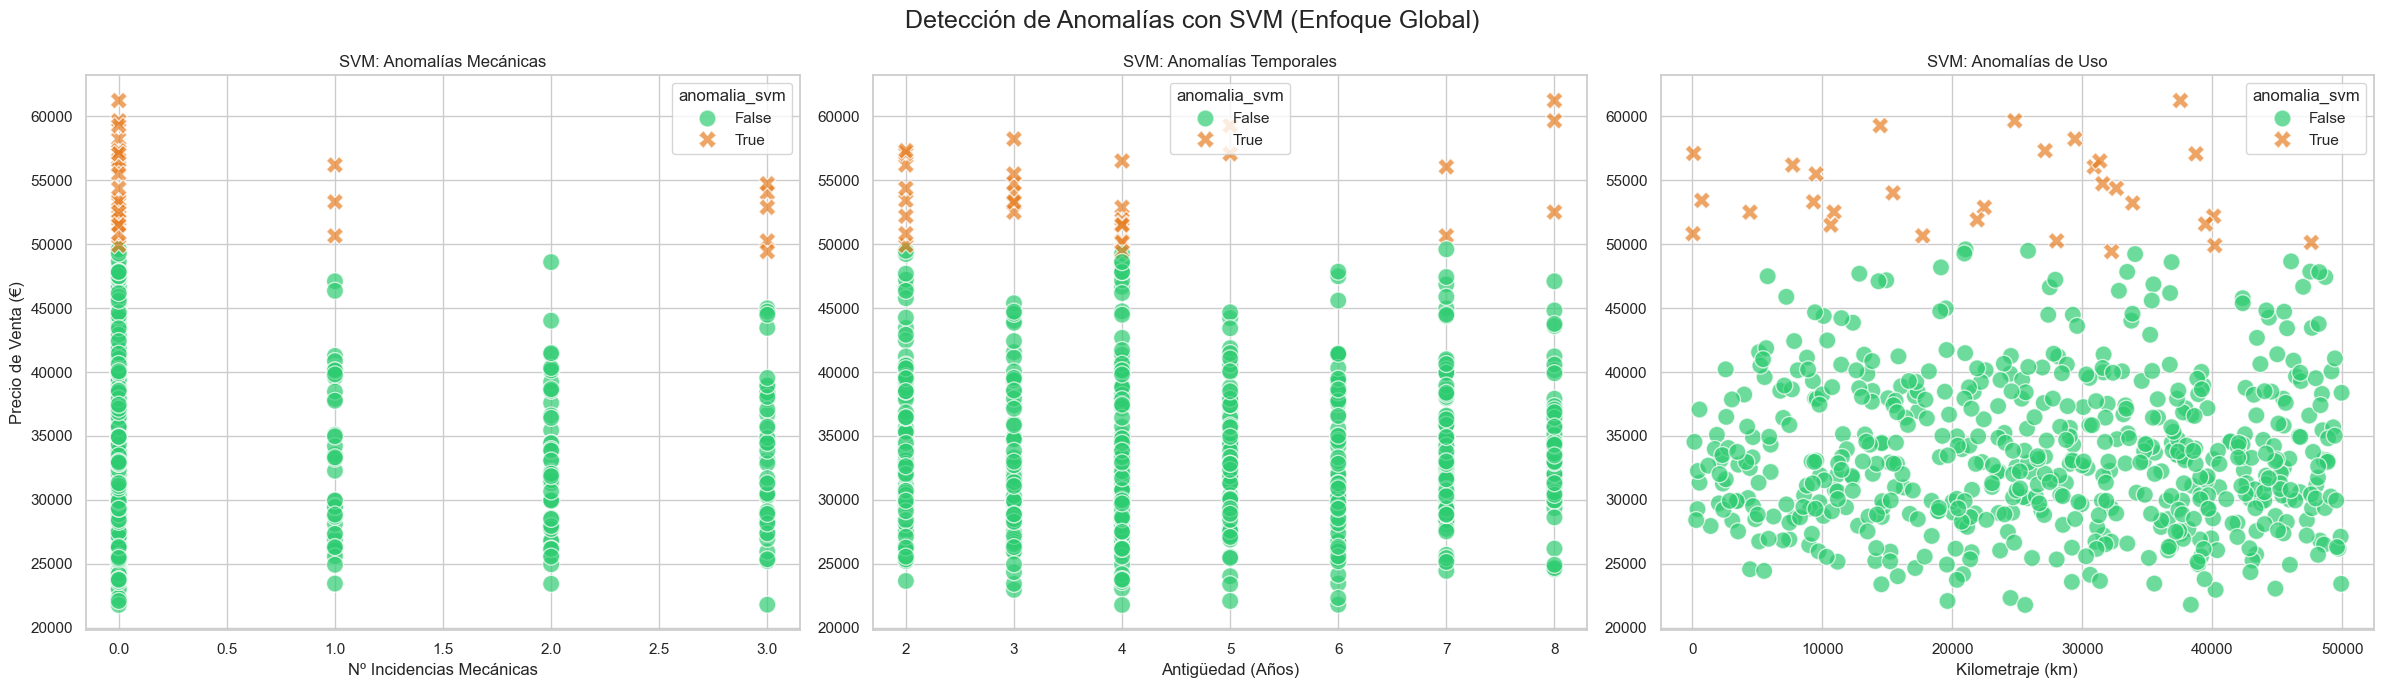

In [93]:
#Visualizacion de anomalías detectadas por SVM
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sns.set_theme(style="whitegrid")

# Estilo para SVM (Usamos Naranja/Verde para distinguir del K-NN)
scatter_params = {
    'hue': 'anomalia_svm', 
    'palette': {False: '#2ecc71', True: '#e67e22'}, # Verde Normal, Naranja Anomalía
    'style': 'anomalia_svm',
    'markers': {False: 'o', True: 'X'}, 
    's': 150, 
    'alpha': 0.7
}

# GRÁFICO 1: Anomalías Mecánicas (SVR)
sns.scatterplot(data=df_anomalias, x='incidencias_mecanicas', y='precio_venta_real', ax=axes[0], **scatter_params)
axes[0].set_title("SVM: Anomalías Mecánicas")
axes[0].set_xlabel("Nº Incidencias Mecánicas")
axes[0].set_ylabel("Precio de Venta (€)")

# GRÁFICO 2: Anomalías Temporales (SVR)
sns.scatterplot(data=df_anomalias, x='antiguedad', y='precio_venta_real', ax=axes[1], **scatter_params)
axes[1].set_title("SVM: Anomalías Temporales")
axes[1].set_xlabel("Antigüedad (Años)")
axes[1].set_ylabel("")

# GRÁFICO 3: Anomalías de Uso (SVR)
sns.scatterplot(data=df_anomalias, x='kilometraje_venta', y='precio_venta_real', ax=axes[2], **scatter_params)
axes[2].set_title("SVM: Anomalías de Uso")
axes[2].set_xlabel("Kilometraje (km)")
axes[2].set_ylabel("")

plt.suptitle(f"Detección de Anomalías con SVM (Enfoque Global)", fontsize=18)
plt.tight_layout()
plt.show()

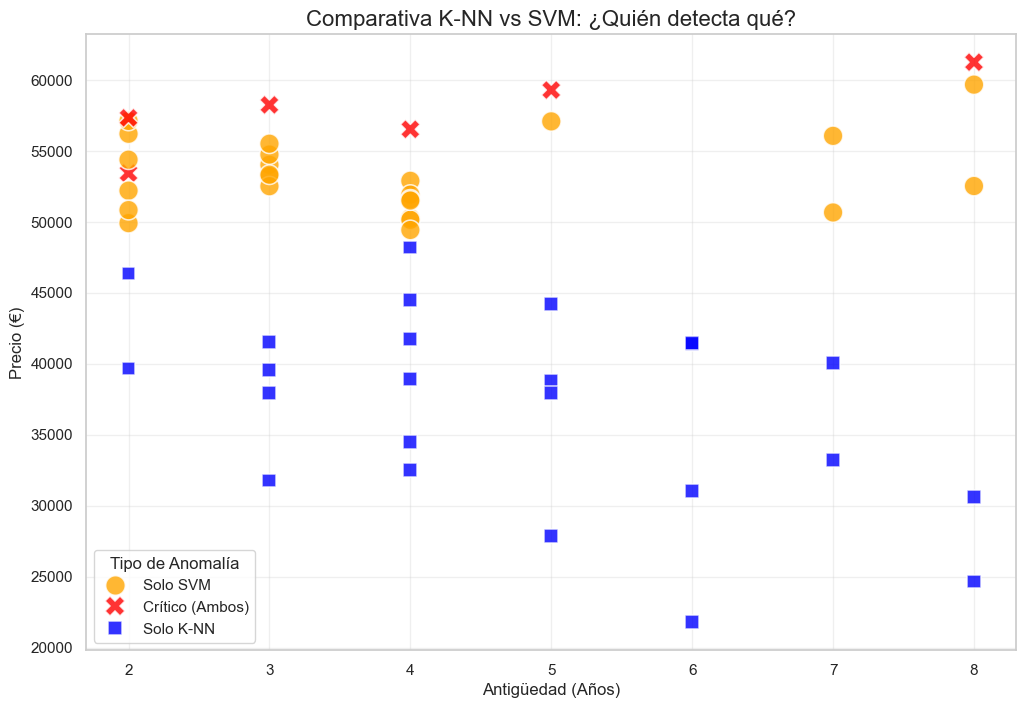

--- Resumen de Coincidencias ---
tipo_anomalia
Normal             546
Solo SVM            24
Solo K-NN           24
Crítico (Ambos)      6
Name: count, dtype: int64

--- Top 3 Anomalías Críticas (Confirmadas por ambos modelos) ---
    marca modelo  precio_venta_real  antiguedad  incidencias_mecanicas
40    BMW     X1              61242           8                      0
60   Ford   Kuga              58232           3                      0
117   Kia   Niro              56512           4                      0


In [94]:
#Comparación entre KNN y SVM
# Definimos la lógica de intersección
condiciones = [
    (df_anomalias['anomalia_svm'] & df_anomalias['anomalia']),  # CRÍTICO: Los dos coinciden
    (df_anomalias['anomalia_svm'] & ~df_anomalias['anomalia']), # Solo SVM
    (~df_anomalias['anomalia_svm'] & df_anomalias['anomalia']), # Solo KNN
    (~df_anomalias['anomalia_svm'] & ~df_anomalias['anomalia']) # Normal
]
etiquetas = ['Crítico (Ambos)', 'Solo SVM', 'Solo K-NN', 'Normal']
df_anomalias['tipo_anomalia'] = np.select(condiciones, etiquetas, default='Normal')
# 2. Filtrar solo los anómalos para limpiar el gráfico
df_anomalos = df_anomalias[df_anomalias['tipo_anomalia'] != 'Normal'].copy()

# 3. VISUALIZACIÓN COMPARATIVA
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_anomalos, 
    x='antiguedad', 
    y='precio_venta_real', 
    hue='tipo_anomalia',
    style='tipo_anomalia',
    palette={'Crítico (Ambos)': 'red', 'Solo SVM': 'orange', 'Solo K-NN': 'blue'},
    s=200, # Puntos grandes para verlos bien
    alpha=0.8
)

plt.title("Comparativa K-NN vs SVM: ¿Quién detecta qué?", fontsize=16)
plt.xlabel("Antigüedad (Años)")
plt.ylabel("Precio (€)")
plt.legend(title="Tipo de Anomalía")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Tabla Resumen (Para la memoria)
print("--- Resumen de Coincidencias ---")
print(df_anomalias['tipo_anomalia'].value_counts())

# Mostrar los casos CRÍTICOS (los más importantes para el negocio)
print("\n--- Top 3 Anomalías Críticas (Confirmadas por ambos modelos) ---")
cols_mostrar = ['marca', 'modelo', 'precio_venta_real', 'antiguedad', 'incidencias_mecanicas']
print(df_anomalias[df_anomalias['tipo_anomalia'] == 'Crítico (Ambos)'][cols_mostrar].head(3))

#### 4.5. Reseñas contradictorias

In [95]:
df_contradicciones_reviews = df_modelado_opiniones.copy()
df_contradicciones_ventas = df_modelado_ventas.copy()

In [96]:
#Creación de diccionario
diccionario_positivo = [
    'eficiente', 'genial', 'excelente', 'recomendable', 'perfecto', 
    'bueno', 'gran', 'cómodo', 'rendimiento', 'relación'
]

diccionario_negativo = [
    'problemático', 'lento', 'caro', 'regular', 'decepcionante', 
    'poco', 'alto', 'elevado'
]

#Funcion para puntuar el texto de las reviews
def calcular_contradiccion(texto):
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    puntuacion = 0
    for palabra in diccionario_positivo:
        if palabra in texto:
            puntuacion += 1
    for palabra in diccionario_negativo:
        if palabra in texto:
            puntuacion -= 1
    return puntuacion

df_contradicciones_reviews['puntuacion_contradiccion'] = df_contradicciones_reviews['texto_review'].apply(calcular_contradiccion)

#El texto es Positivo (Score > 0) pero dice "No"
contradiccion_P = (df_contradicciones_reviews['puntuacion_contradiccion'] > 0) & (df_contradicciones_reviews['recomendacion'] == 'No')

#El texto es Negativo (Score < 0) pero dice "Sí"
contradiccion_N = (df_contradicciones_reviews['puntuacion_contradiccion'] < 0) & (df_contradicciones_reviews['recomendacion'] == 'Si')

# Identificamos los vehículos tóxicos
reviews_toxicas = df_contradicciones_reviews[contradiccion_P | contradiccion_N]
ids_vehiculos_toxicos = reviews_toxicas['vehiculo_id'].unique()

print(f"Contradicciones Detectadas por Diccionario: {len(reviews_toxicas)}")
print(f"  -> Hablan bien pero no recomiendan: {contradiccion_P.sum()}")
print(f"  -> Hablan mal pero sí recomiendan: {contradiccion_N.sum()}")

Contradicciones Detectadas por Diccionario: 115
  -> Hablan bien pero no recomiendan: 0
  -> Hablan mal pero sí recomiendan: 115


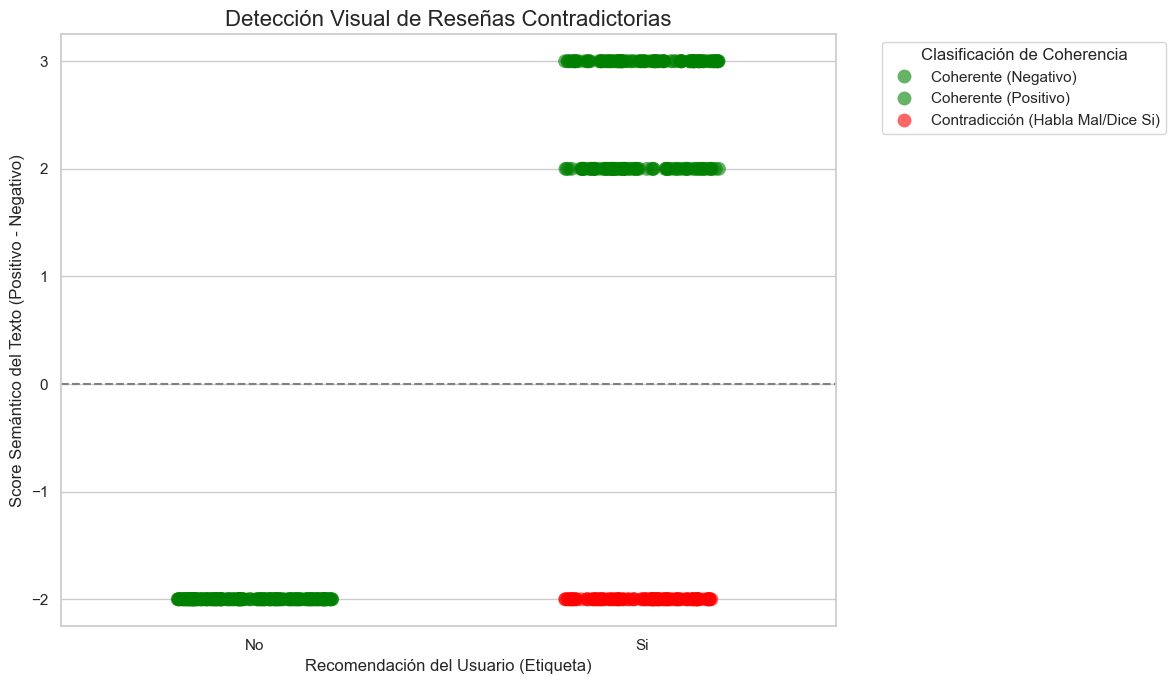

In [97]:
#Visualización de las contradicciones
condiciones = [
    (df_contradicciones_reviews['puntuacion_contradiccion'] > 0) & (df_contradicciones_reviews['recomendacion'] == 'Si'), # Coherente Positivo
    (df_contradicciones_reviews['puntuacion_contradiccion'] < 0) & (df_contradicciones_reviews['recomendacion'] == 'No'), # Coherente Negativo
    (df_contradicciones_reviews['puntuacion_contradiccion'] > 0) & (df_contradicciones_reviews['recomendacion'] == 'No'), # CONTRADICCIÓN A
    (df_contradicciones_reviews['puntuacion_contradiccion'] < 0) & (df_contradicciones_reviews['recomendacion'] == 'Si'), # CONTRADICCIÓN B
]

etiquetas = ['Coherente (Positivo)', 'Coherente (Negativo)', 'Contradicción (Habla Bien/Dice No)', 'Contradicción (Habla Mal/Dice Si)']

# Asignamos etiqueta, por defecto "Neutro" si score es 0
df_contradicciones_reviews['tipo_analisis'] = np.select(condiciones, etiquetas, default='Neutro')

# Filtramos los neutros para el gráfico para que se vea más limpio
df_plot = df_contradicciones_reviews[df_contradicciones_reviews['tipo_analisis'] != 'Neutro'].copy()

#Grafico de visualización
plt.figure(figsize=(12, 7))

# Usamos jitter para que los puntos no se superpongan y se vea el volumen
sns.stripplot(
    data=df_plot, 
    x='recomendacion', 
    y='puntuacion_contradiccion', 
    hue='tipo_analisis',
    palette={
        'Coherente (Positivo)': 'green', 
        'Coherente (Negativo)': 'green', 
        'Contradicción (Habla Bien/Dice No)': 'red', 
        'Contradicción (Habla Mal/Dice Si)': 'red'
    },
    size=10, 
    alpha=0.6,
    jitter=0.2
)

# Línea de neutralidad
plt.axhline(0, color='gray', linestyle='--')

# Anotaciones explicativas
plt.title("Detección Visual de Reseñas Contradictorias", fontsize=16)
plt.xlabel("Recomendación del Usuario (Etiqueta)", fontsize=12)
plt.ylabel("Score Semántico del Texto (Positivo - Negativo)", fontsize=12)

plt.legend(title="Clasificación de Coherencia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Predicción para el precio habiendo eliminado los vehículos con contradicciones

In [98]:
# Preparación del dataset de ventas eliminado los vehiculos tóxicos
df_ventas_limpio = df_modelado_ventas.copy()
df_ventas_limpio = df_ventas_limpio[~df_ventas_limpio['vehiculo_id'].isin(ids_vehiculos_toxicos)].copy()

df_ventas_limpio.reset_index(drop=True, inplace=True)
df_ventas_limpio

,venta_id,vehiculo_id,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,marca,modelo,...,region_Madrid,region_País Vasco,region_Valencia,fuel_Diésel,fuel_Eléctrico,fuel_Gasolina,fuel_Híbrido,transmision_encoded,segmento_encoded,emisiones_encoded
0,VT001,VH001,34536,168,0,992,0,12937,Peugeot,208,...,0,0,0,0,0,0,1,0,1,1
1,VT002,VH001,31929,9835,1,992,0,6894,Peugeot,208,...,0,1,0,0,0,0,1,0,1,1
2,VT003,VH001,30964,16270,3,992,0,10366,Peugeot,208,...,0,1,0,0,0,0,1,0,1,1
3,VT005,VH003,34964,20361,2,896,3,18098,Kia,Ev6,...,0,0,0,0,0,0,1,0,5,0
4,VT006,VH004,35443,48468,4,1004,2,8611,Ford,Puma,...,0,0,1,0,0,1,0,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,VT596,VH299,37130,21468,6,802,0,30401,Citroën,C4,...,0,0,0,0,0,0,1,0,3,2
413,VT597,VH299,38550,37381,1,802,0,28489,Citroën,C4,...,0,1,0,0,0,0,1,0,3,2
414,VT598,VH300,39811,30305,1,872,1,27563,Kia,Picanto,...,0,0,0,0,0,1,0,1,4,0
415,VT599,VH300,37445,9781,0,872,0,26783,Kia,Picanto,...,0,1,0,0,0,1,0,1,4,0


In [99]:
# Preparación del dataset de opiniones

opiniones_limpias = df_modelado_opiniones.copy()
opiniones_limpias = opiniones_limpias.groupby('vehiculo_id').agg({
    'puntuacion_conjunta': 'mean',  # Promedio de puntuación de contradicción por vehículo
    'recomendacion': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
}).reset_index()

# Unimos con el dataset de ventas limpio
df_final_limpio = pd.merge(df_ventas_limpio, opiniones_limpias, on='vehiculo_id', how='inner')

df_final_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   venta_id                   306 non-null    object 
 1   vehiculo_id                306 non-null    object 
 2   precio_venta_real          306 non-null    int64  
 3   kilometraje_venta          306 non-null    int64  
 4   servicios_realizados       306 non-null    int64  
 5   coste_mantenimiento_anual  306 non-null    int64  
 6   incidencias_mecanicas      306 non-null    int64  
 7   valor_residual_estimado    306 non-null    int64  
 8   marca                      306 non-null    object 
 9   modelo                     306 non-null    object 
 10  transmision                306 non-null    object 
 11  potencia_cv                306 non-null    int64  
 12  cilindrada                 306 non-null    int64  
 13  emisiones_co2              306 non-null    int64  

In [100]:
features_precio = [
    # Configuración del vehículo
    'transmision_encoded',
    'fuel_Gasolina',
    'fuel_Híbrido',
    'fuel_Eléctrico',

    # Características técnicas
    'potencia_cv',
    'eficiencia_global',

    # Uso del vehículo
    'antiguedad',
    'kilometraje_venta',

    # Mantenimiento
    'coste_mantenimiento_anual',
    'incidencias_mecanicas',

    # Reseñas agregadas
    'puntuacion_conjunta',
    'recomendacion'

]

df_rf_precio_contradicciones = df_final_limpio[
    features_precio + ['precio_venta_real']

]

# Mapeamos la recomendación
df_rf_precio_contradicciones['recomendacion'] = df_rf_precio_contradicciones['recomendacion'].map({
    'Si': 1,
    'No': 0
})

df_rf_precio_contradicciones

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\3709800435.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rf_precio_contradicciones['recomendacion'] = df_rf_precio_contradicciones['recomendacion'].map({


,transmision_encoded,fuel_Gasolina,fuel_Híbrido,fuel_Eléctrico,potencia_cv,eficiencia_global,antiguedad,kilometraje_venta,coste_mantenimiento_anual,incidencias_mecanicas,puntuacion_conjunta,recomendacion,precio_venta_real
0,0,0,1,0,147,6.2,8,168,992,0,4.3,1,34536
1,0,0,1,0,147,6.2,8,9835,992,0,4.3,1,31929
2,0,0,1,0,147,6.2,8,16270,992,0,4.3,1,30964
3,1,1,0,0,237,5.2,4,16064,876,3,4.8,1,38881
4,1,1,0,0,237,5.2,4,45446,876,0,4.8,1,37915
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,0,0,1,0,175,4.4,3,21468,802,0,4.4,1,37130
302,0,0,1,0,175,4.4,3,37381,802,0,4.4,1,38550
303,1,1,0,0,235,4.9,4,30305,872,1,3.3,0,39811
304,1,1,0,0,235,4.9,4,9781,872,0,3.3,0,37445


In [101]:
#Entrenamiento del modelo Random Forest para predecir el precio de venta real

#Dividir en características y target
X = df_rf_precio_contradicciones.drop(columns=['precio_venta_real'])
y = df_rf_precio_contradicciones['precio_venta_real']

#Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Modelo Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=6, min_samples_split=10)
rf.fit(X_train, y_train)

# Predicción
y_pred = rf.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# Evaluación del modelo

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

R²: 0.865
RMSE: 2454.32
MAE: 1990.93


A primera vista al ser el dataset sin datos contradictorios debería mejorar el modelo, pero no nos encontramos con eso. Esto se debe principalmente a la diferencia en el volumen de datos con el que hemos tenido que trabajar. Y como hemos aplicado el algoritmo de Random Forest para predecir el precio (es un algoritmo que funciona mejor con muchos datos), ha generalizado peor. Con este experimento queda demostrado que a veces que más valioso conservar el volumen de datos que filtrar.

#### 4.6 Predicción del precio de venta

Ya que en puntos anteriores hemos tenido buenos resultados con el dataset vamos a escoger los paramentros con los que nos salieron

In [102]:
#  Dataset base 
df_modelos_prediccion_precio = df_rf_precio.copy()

In [103]:
# Variables explicativas y objetivo
X = df_modelos_prediccion_precio.drop(columns='precio_venta_real')
y = df_modelos_prediccion_precio['precio_venta_real']

In [104]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [105]:
from sklearn.preprocessing import StandardScaler
# Escalado de variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

# Definicion de modelos
#   Se intenta hacer de una manera especifica para facilitar la 
#   comparacion de los resultados mas facilmente al acabar
modelo_multiple = LinearRegression()
modelo_arbol = DecisionTreeRegressor(max_depth=6, random_state=42)
modelo_mlp = MLPRegressor(hidden_layer_sizes=(50,50),
                          max_iter=2000,
                          random_state=42)

In [107]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Modelo SVM reconstruido para que funcione con pipelines
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# Parametros
param_grid = {
    'svr__kernel': ['rbf'],
    'svr__C': [1, 10, 50, 100, 500],
    'svr__gamma': ['scale', 0.01, 0.1, 1],
    'svr__epsilon': [0.1, 0.5, 1]
}

grid_search = GridSearchCV(
    pipeline_svm,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

mejor_svm = grid_search.best_estimator_

In [108]:
# Array con todos los modelos unidos
modelos = {
    "Regresion Multiple": modelo_multiple,
    "Árbol de Decisión": modelo_arbol,
    "SVM": mejor_svm,
    "Perceptron Multicapa": modelo_mlp
}

In [109]:
# Entrenamiento y evaluación
resultados = []

for nombre, modelo in modelos.items():
    
    # Para SVM y Perceptron multicapa usamos datos escalados
    if nombre in ["SVM", "Perceptron Multicapa"]:
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
    
    # Métricas
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # R2 ajustado
    n = X_test.shape[0]
    p = X_test.shape[1]
    r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    resultados.append([nombre, mse, rmse, mae, r2, r2_ajustado])

c:\Users\Ccp0897\anaconda3\envs\piaentorno\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [110]:
# Resultados y gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Diccionario para guardar predicciones
predicciones = {}

for nombre, modelo in modelos.items():
    
    # Para SVM y Perceptron multicapa usamos datos escalados
    if nombre in ["SVM", "Perceptron Multicapa"]:
        y_pred = modelo.predict(X_test_scaled)
    else:
        y_pred = modelo.predict(X_test)
    
    predicciones[nombre] = y_pred

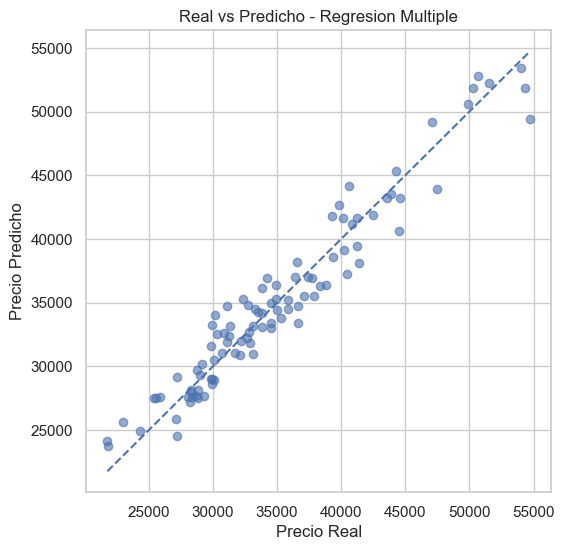

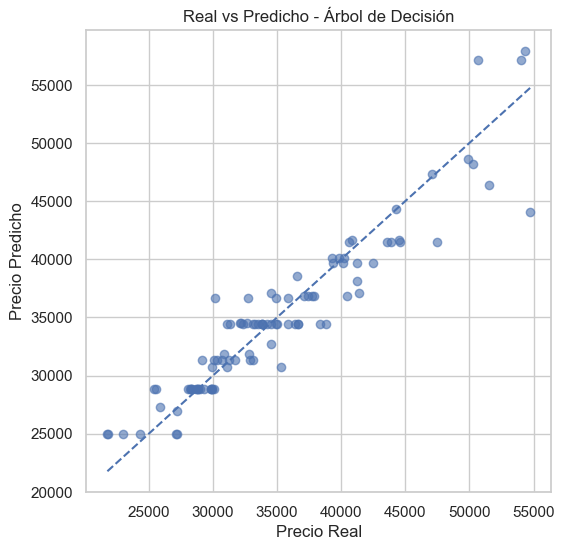

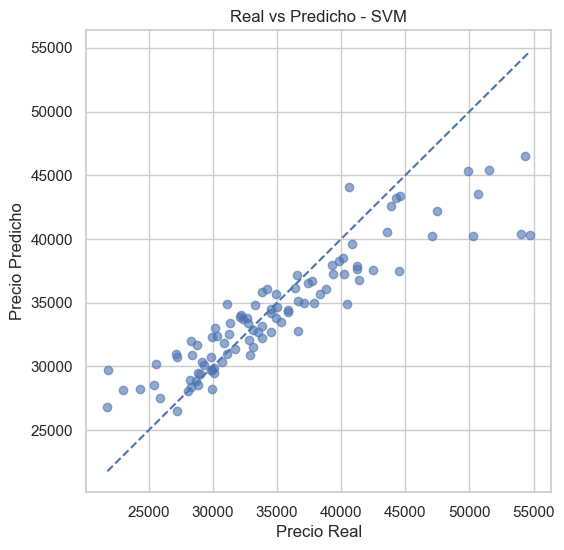

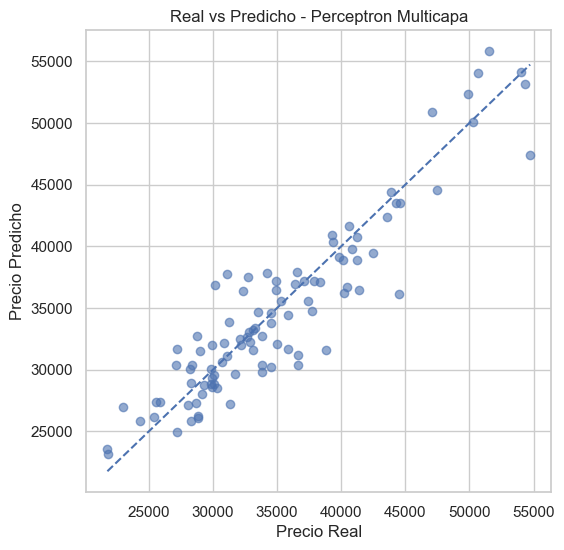

In [112]:
# Precio real vs predicho
for nombre, y_pred in predicciones.items():
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--'
    )
    plt.title(f'Real vs Predicho - {nombre}')
    plt.xlabel('Precio Real')
    plt.ylabel('Precio Predicho')
    plt.show() # Mostramos los graficos de predicción de cada modelo

A primera vista podemos intuir que la regresion multiple nos proporciona mejores resultados que los otros modelos por la concentracion que tiene de los puntos en torno a la linea

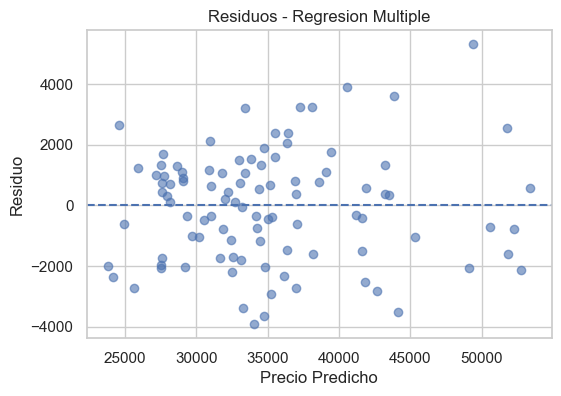

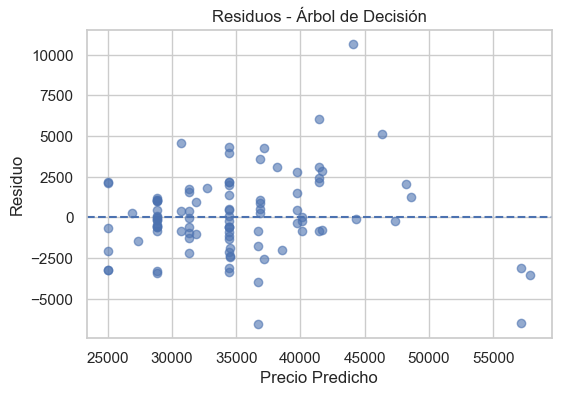

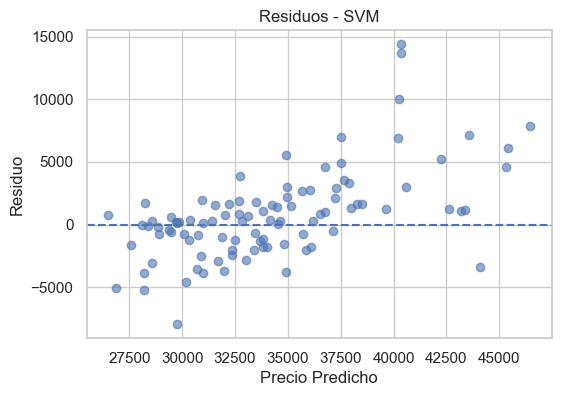

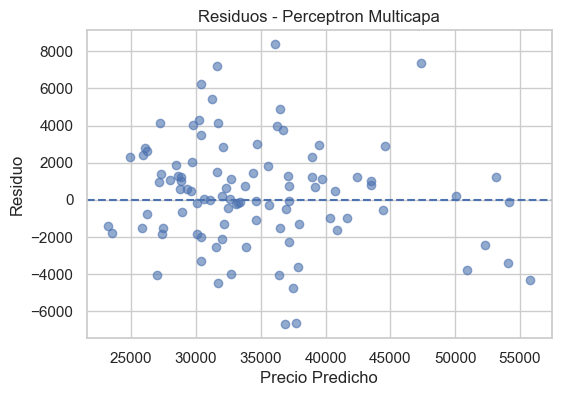

In [113]:

# Gráfico de residuos 
for nombre, y_pred in predicciones.items():
    
    residuos = y_test - y_pred
    
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuos, alpha=0.6)
    plt.axhline(0, linestyle='--')
    plt.title(f'Residuos - {nombre}')
    plt.xlabel('Precio Predicho')
    plt.ylabel('Residuo')
    plt.show() # Mostramos los residuos de cada modelo

In [114]:
# Tabla comparativa final de los modelos
df_resultados = pd.DataFrame(resultados,
                             columns=["Modelo",
                                      "MSE",
                                      "RMSE",
                                      "MAE",
                                      "R2",
                                      "R2 Ajustado"])

# Ordenamos por R2 para facilitar la comparación
df_resultados.sort_values(by="R2", ascending=False) 

,Modelo,MSE,RMSE,MAE,R2,R2 Ajustado
0,Regresion Multiple,3.347533e+06,1829.626469,1501.117320,0.936912,0.927149
1,Árbol de Decisión,6.186497e+06,2487.266939,1790.153408,0.883409,0.865365
3,Perceptron Multicapa,8.102632e+06,2846.512291,2156.956010,0.847297,0.823665
2,SVM,1.322694e+07,3636.886370,2515.299613,0.750724,0.712146


**Regresión Lineal Múltiple**

El modelo explica aproximadamente el 93% de la variabilidad del precio, lo que indica que la relación entre las variables explicativas y el precio es altamente estructurada y cercana a lineal. Además, el R² ajustado (0.9271) confirma que el modelo no está sobreajustado.

**Arbol de Decisión**

El modelo tiene buen rendimiento, pero inferior a la regresión lineal. El árbol puede perder precisión cuando la relación es más continua que segmentada.

**Perceptron Multicapa**

Aunque es un modelo más complejo, no supera a la regresión lineal. Esto sugiere que el problema no requiere una estructura altamente no lineal.

**SVM**

Tras la optimización de hiperparámetros mediante validación cruzada, el modelo SVM alcanza un R² de 0.75, mostrando un rendimiento aceptable aunque inferior a la regresión lineal y al árbol de decisión.

##### Resultado final

Tras el analisis de los modelos determinamos que se selecciona la Regresión Lineal Múltiple como modelo definitivo porque:

- Presenta el mayor R²

- Tiene el menor RMSE y MAE

- El R² ajustado confirma estabilidad

- Es el modelo más interpretable

- No muestra indicios de sobreajuste

### Fase 5: Interpretación y Evaluación

#### 5.1. Aplica Algoritmos para la clasificación de Segmento de Mercado

In [135]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [136]:
# Cargamos el dataset de ventas (que contiene las características del coche y el segmento)
df = df_modelado_ventas.copy()
df

,venta_id,vehiculo_id,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,marca,modelo,...,region_Madrid,region_País Vasco,region_Valencia,fuel_Diésel,fuel_Eléctrico,fuel_Gasolina,fuel_Híbrido,transmision_encoded,segmento_encoded,emisiones_encoded
0,VT001,VH001,34536,168,0,992,0,12937,Peugeot,208,...,0,0,0,0,0,0,1,0,1,1
1,VT002,VH001,31929,9835,1,992,0,6894,Peugeot,208,...,0,1,0,0,0,0,1,0,1,1
2,VT003,VH001,30964,16270,3,992,0,10366,Peugeot,208,...,0,1,0,0,0,0,1,0,1,1
3,VT004,VH002,31897,44127,0,1030,0,6739,Hyundai,i20,...,0,0,0,0,0,1,0,0,2,1
4,VT005,VH003,34964,20361,2,896,3,18098,Kia,Ev6,...,0,0,0,0,0,0,1,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,VT596,VH299,37130,21468,6,802,0,30401,Citroën,C4,...,0,0,0,0,0,0,1,0,3,2
596,VT597,VH299,38550,37381,1,802,0,28489,Citroën,C4,...,0,1,0,0,0,0,1,0,3,2
597,VT598,VH300,39811,30305,1,872,1,27563,Kia,Picanto,...,0,0,0,0,0,1,0,1,4,0
598,VT599,VH300,37445,9781,0,872,0,26783,Kia,Picanto,...,0,1,0,0,0,1,0,1,4,0


In [137]:
# Separar el target (segmento)
le = LabelEncoder()
y = le.fit_transform(df['segmento'])
clases = le.classes_
print(y)
print(f"Segmentos a clasificar: {clases}")

[0 0 0 4 1 3 3 3 0 0 0 0 0 2 2 0 0 0 0 3 1 1 1 2 0 3 3 3 3 0 0 0 0 4 0 0 2
 2 2 3 3 0 0 0 0 4 0 0 0 0 2 2 3 3 3 3 0 0 3 3 3 0 0 0 0 3 3 3 4 4 4 0 0 2
 2 4 4 4 3 3 3 4 4 3 3 0 0 0 4 4 4 4 4 1 1 1 4 4 0 4 4 4 2 3 3 4 4 4 3 3 3
 4 4 4 3 0 3 3 3 4 2 2 2 2 2 3 3 0 0 0 4 4 3 3 4 4 4 1 1 1 0 0 0 1 1 4 4 3
 3 3 3 3 0 0 0 2 2 2 2 2 2 0 4 4 4 3 3 4 4 4 3 3 3 0 1 1 1 2 0 2 2 3 4 3 3
 3 3 3 0 4 4 4 4 0 0 0 2 4 0 0 0 3 0 2 2 2 4 0 0 3 2 2 0 4 2 0 0 0 0 2 2 3
 3 4 4 4 4 2 2 4 3 3 4 4 4 4 4 4 4 3 0 0 0 0 0 0 0 3 3 4 4 3 3 3 3 4 4 4 2
 2 0 0 0 4 4 4 3 0 0 3 3 1 1 0 0 2 3 0 0 0 0 3 3 3 3 3 3 0 3 3 3 2 0 4 4 4
 3 3 3 3 0 0 0 3 3 3 3 4 4 4 2 2 0 0 0 0 3 3 3 0 0 0 3 3 3 0 0 0 0 0 2 1 1
 1 0 0 0 2 3 3 3 3 3 4 4 4 4 3 0 0 0 0 0 0 0 0 3 3 3 3 2 2 2 0 0 0 0 0 0 2
 2 2 0 0 4 4 0 3 3 3 3 3 3 3 3 0 0 3 3 4 4 3 0 4 4 4 0 0 0 0 0 0 4 0 1 0 0
 0 3 0 0 0 0 0 0 4 4 0 0 0 2 0 3 3 3 3 3 3 4 4 0 4 3 2 0 0 0 3 2 2 2 0 0 3
 3 3 0 0 0 0 3 3 3 2 2 2 3 0 1 1 3 3 0 0 0 0 0 0 0 2 2 2 2 2 3 3 3 3 3 3 3
 4 0 0 0 3 3 0 0 0 3 0 0 

In [149]:
# Ignoramos IDs y variables de "estado" que claramente no definen un segmento de fábrica
cols_a_ignorar = ['vehiculo_id', 'venta_id', 'fecha_venta', 'precio_venta_real', 
                  'kilometraje_venta', 'incidencias_mecanicas', 'coste_mantenimiento_anual', 
                  'antiguedad', 'valor_residual_estimado', 'segmento', 'segmento_encoded', 'potencia_cv_normalizado', 'cilindrada_normalizado']
features_candidatas = [col for col in df.columns if col not in cols_a_ignorar and pd.api.types.is_numeric_dtype(df[col])]
X_all = df[features_candidatas].fillna(0)
features_candidatas

['servicios_realizados',
 'potencia_cv',
 'cilindrada',
 'emisiones_co2',
 'precio_base',
 'eficiencia_global',
 'ratio_precio_potencia',
 'indice_fiabilidad',
 'anio_venta',
 'mes_venta',
 'region_Andalucía',
 'region_Cataluña',
 'region_Madrid',
 'region_País Vasco',
 'region_Valencia',
 'fuel_Diésel',
 'fuel_Eléctrico',
 'fuel_Gasolina',
 'fuel_Híbrido',
 'transmision_encoded',
 'emisiones_encoded']

✅ Las 6 características más importantes son: ['potencia_cv', 'ratio_precio_potencia', 'eficiencia_global', 'precio_base']


C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_428\673798749.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.head(8).values, y=importancias.head(8).index, palette='viridis')


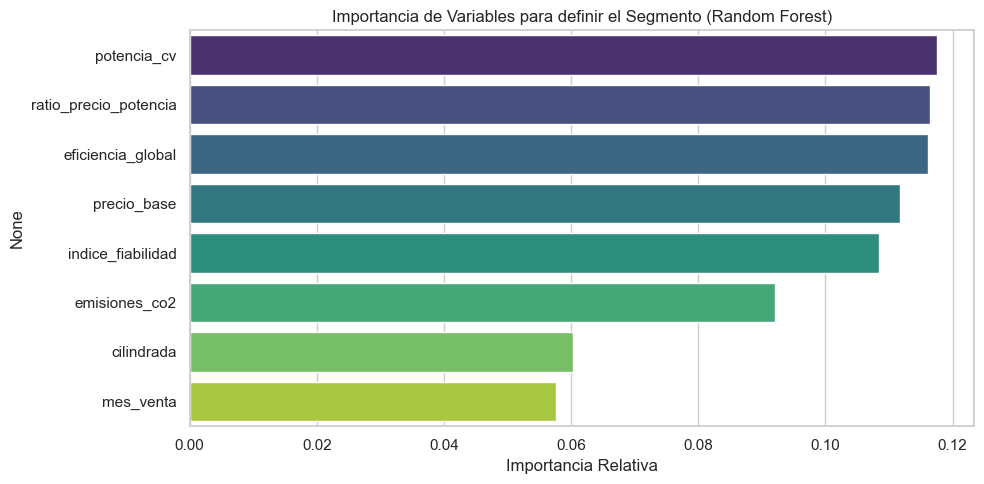

In [ ]:
# Selección de características basada en la importancia del modelo Random Forest
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_all, y)
# Obtener importancia y seleccionar las Top 5
importancias = pd.Series(rf_selector.feature_importances_, index=X_all.columns).sort_values(ascending=False)
top_features = importancias.head(4).index.tolist()
print(f" Las 4 características más importantes son: {top_features}")

# Visualizar importancia
plt.figure(figsize=(10, 5))
sns.barplot(x=importancias.head(8).values, y=importancias.head(8).index, palette='viridis')
plt.title('Importancia de Variables para definir el Segmento (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

In [164]:
X_optimo = X_all[top_features]
X_train, X_test, y_train, y_test = train_test_split(X_optimo, y, test_size=0.2, random_state=42, stratify=y)

# Escalado (Crítico para KNN y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [180]:
# Entrenamiento y evaluación de modelos
models_params = {
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {'var_smoothing': [1e-9, 1e-8, 1e-7]}
    },
    'K-NN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    'Árbol de Decisión': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [3, 5, 7, 10], 'criterion': ['gini', 'entropy']}
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {'C': [1000], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 10]}
    }
}

resultados = []

for name, mp in models_params.items():
    # GridSearch con Cross-Validation de 5 particiones
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1_weighted', n_jobs=-1)
    clf.fit(X_train_scaled, y_train)
    
    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)
    
    # Cálculo de métricas (average='weighted' para manejar múltiples clases desbalanceadas)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0) # Sensibilidad
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # ROC-AUC Multiclase (OVR: One vs Rest)
    try:
        roc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    except:
        roc = np.nan # Por si falla la convergencia en alguna clase aislada
        
    resultados.append({
        'Modelo': name,
        'Mejor Hiperparámetro': str(clf.best_params_),
        'Exactitud (Accuracy)': acc,
        'Precisión': prec,
        'Sensibilidad': rec,
        'F1-Score': f1,
        'ROC-AUC': roc
    })


--- TABLA DE MÉTRICAS Y MEJORES HIPERPARÁMETROS ---
                                        Mejor Hiperparámetro  \
Modelo                                                         
Naive Bayes                         {'var_smoothing': 1e-09}   
K-NN               {'n_neighbors': 3, 'weights': 'distance'}   
Árbol de Decisión  {'criterion': 'entropy', 'max_depth': 10}   
SVM                {'C': 1000, 'gamma': 10, 'kernel': 'rbf'}   

                   Exactitud (Accuracy)  Precisión  Sensibilidad  F1-Score  \
Modelo                                                                       
Naive Bayes                    0.308333   0.324226      0.308333  0.279174   
K-NN                           0.841667   0.844818      0.841667  0.839852   
Árbol de Decisión              0.750000   0.761564      0.750000  0.745890   
SVM                            0.858333   0.875352      0.858333  0.858355   

                    ROC-AUC  
Modelo                       
Naive Bayes        0.599026  
K-N

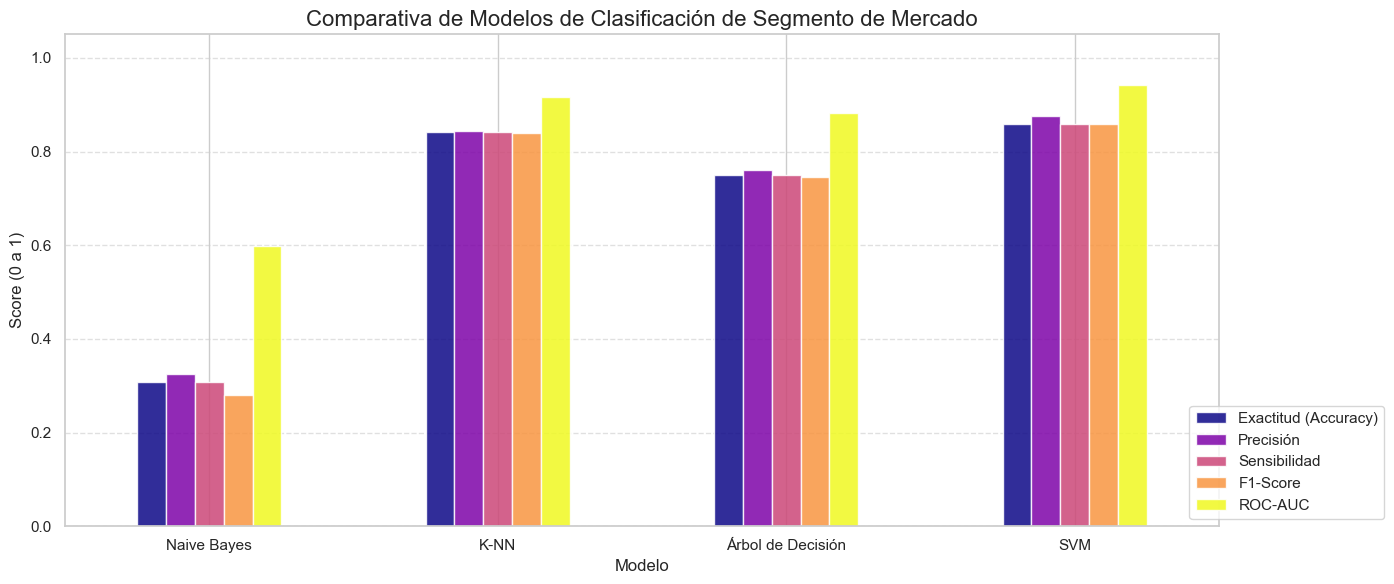

In [181]:
#Resultados finales
df_resultados = pd.DataFrame(resultados).set_index('Modelo')

pd.set_option('display.max_colwidth', None)
print("\n--- TABLA DE MÉTRICAS Y MEJORES HIPERPARÁMETROS ---")
print(df_resultados)

# Visualización comparativa
metricas_plot = ['Exactitud (Accuracy)', 'Precisión', 'Sensibilidad', 'F1-Score', 'ROC-AUC']
df_resultados[metricas_plot].plot(kind='bar', figsize=(14, 6), colormap='plasma', alpha=0.85)

plt.title('Comparativa de Modelos de Clasificación de Segmento de Mercado', fontsize=16)
plt.ylabel('Score (0 a 1)')
plt.ylim(0.0, 1.05) # Hacemos zoom en la parte superior para ver diferencias
plt.xticks(rotation=0)
plt.legend(loc='lower right', bbox_to_anchor=(1.15, 0))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### 5.2 Modelo de recomendación

In [211]:
df_recomendacion_opiniones = df_modelado_opiniones.copy()
df_recomendacion_ventas = df_modelado_ventas.copy()

In [212]:
# Unimos para asociar cada cliente_id con el coche que valoró y sus especificaciones
# Usamos un inner join para asegurar que tenemos tanto la opinión como los datos técnicos
df_interacciones = pd.merge(
    df_recomendacion_ventas,
    df_recomendacion_opiniones, 
    on='vehiculo_id', 
    how='inner'
)

In [213]:
df_interacciones.head()

,venta_id,vehiculo_id,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,marca,modelo,...,review_id,cliente_id,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad,recomendacion,texto_review
0,VT001,VH001,34536,168,0,992,0,12937,Peugeot,208,...,RV130,CUST071,4.3,4.2,4.6,4.4,4.5,4.5,Si,"Genial vehículo, gran rendimiento"
1,VT002,VH001,31929,9835,1,992,0,6894,Peugeot,208,...,RV130,CUST071,4.3,4.2,4.6,4.4,4.5,4.5,Si,"Genial vehículo, gran rendimiento"
2,VT003,VH001,30964,16270,3,992,0,10366,Peugeot,208,...,RV130,CUST071,4.3,4.2,4.6,4.4,4.5,4.5,Si,"Genial vehículo, gran rendimiento"
3,VT004,VH002,31897,44127,0,1030,0,6739,Hyundai,i20,...,RV195,CUST163,3.3,3.5,3.7,2.8,2.4,3.5,No,"Problemático, precio elevado"
4,VT004,VH002,31897,44127,0,1030,0,6739,Hyundai,i20,...,RV412,CUST064,3.8,4.3,4.2,3.2,4.1,3.7,Si,"Problemático, poco espacio"


In [214]:
# Transformamos el texto en un número (1 = Sí, 0 = No)
df_interacciones['tasa_recomendacion'] = df_interacciones['recomendacion'].map({'Si': 1, 'No': 0})

features_opiniones = ['confort', 'seguridad', 'eficiencia', 'diseno', 'fiabilidad', 'puntuacion_conjunta', 'tasa_recomendacion']
features_tecnicas = ['potencia_cv', 'precio_base', 'eficiencia_global', 'coste_mantenimiento_anual', 'cilindrada']

todas_las_features = features_tecnicas + features_opiniones

df_interacciones[features_opiniones] = df_interacciones[features_opiniones].fillna(df_interacciones[features_opiniones].mean())
df_interacciones

,venta_id,vehiculo_id,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,marca,modelo,...,cliente_id,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad,recomendacion,texto_review,tasa_recomendacion
0,VT001,VH001,34536,168,0,992,0,12937,Peugeot,208,...,CUST071,4.3,4.2,4.6,4.4,4.5,4.5,Si,"Genial vehículo, gran rendimiento",1
1,VT002,VH001,31929,9835,1,992,0,6894,Peugeot,208,...,CUST071,4.3,4.2,4.6,4.4,4.5,4.5,Si,"Genial vehículo, gran rendimiento",1
2,VT003,VH001,30964,16270,3,992,0,10366,Peugeot,208,...,CUST071,4.3,4.2,4.6,4.4,4.5,4.5,Si,"Genial vehículo, gran rendimiento",1
3,VT004,VH002,31897,44127,0,1030,0,6739,Hyundai,i20,...,CUST163,3.3,3.5,3.7,2.8,2.4,3.5,No,"Problemático, precio elevado",0
4,VT004,VH002,31897,44127,0,1030,0,6739,Hyundai,i20,...,CUST064,3.8,4.3,4.2,3.2,4.1,3.7,Si,"Problemático, poco espacio",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,VT596,VH299,37130,21468,6,802,0,30401,Citroën,C4,...,CUST068,4.4,4.5,4.5,5.0,5.0,4.1,Si,"Eficiente vehículo, muy cómodo",1
1008,VT597,VH299,38550,37381,1,802,0,28489,Citroën,C4,...,CUST068,4.4,4.5,4.5,5.0,5.0,4.1,Si,"Eficiente vehículo, muy cómodo",1
1009,VT598,VH300,39811,30305,1,872,1,27563,Kia,Picanto,...,CUST088,3.3,2.6,4.0,2.5,4.4,2.9,No,"Regular, precio elevado",0
1010,VT599,VH300,37445,9781,0,872,0,26783,Kia,Picanto,...,CUST088,3.3,2.6,4.0,2.5,4.4,2.9,No,"Regular, precio elevado",0


In [215]:
# CONSTRUCCIÓN DEL PERFIL DE CLIENTE (Técnico + Gustos)
perfiles_clientes = df_interacciones.groupby('cliente_id')[todas_las_features].mean().reset_index()


#Calculamos el "Segmento Favorito" de cada cliente
segmento_favorito = df_interacciones.groupby('cliente_id')['segmento'].agg(lambda x: x.mode()[0]).reset_index()
perfiles_clientes = pd.merge(perfiles_clientes, segmento_favorito, on='cliente_id')

In [216]:
# ENTRENAMIENTO DE LOS MODELOS K-NN
from sklearn.neighbors import NearestNeighbors
# 1. K-NN de Clientes (Busca clientes con gustos y presupuestos parecidos)
scaler_cli = StandardScaler()
X_clientes_scaled = scaler_cli.fit_transform(perfiles_clientes[todas_las_features])

# Usamos 'cosine' para similitud de gustos
knn_clientes = NearestNeighbors(n_neighbors=10, metric='cosine') 
knn_clientes.fit(X_clientes_scaled)

,n_neighbors,10
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [217]:
# 2. K-NN de Catálogo de Coches
# El perfil del coche incluye sus specs técnicas y sus notas medias
catalogo_coches = df_interacciones.groupby(['vehiculo_id', 'marca', 'modelo', 'segmento'])[todas_las_features].mean().reset_index()

scaler_coches = StandardScaler()
X_coches_scaled = scaler_coches.fit_transform(catalogo_coches[todas_las_features])

knn_coches = NearestNeighbors(n_neighbors=3, metric='cosine')
knn_coches.fit(X_coches_scaled)

,n_neighbors,3
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [220]:
# Funcion de recomendación 
def recomendar_vehiculos_integral(target_cliente_id):
    print(f"\n" + "="*70)
    print(f"Analizando perfil integral del Cliente ID: {target_cliente_id}")
    print("="*70)
    
    if target_cliente_id not in perfiles_clientes['cliente_id'].values:
        print("Cliente no encontrado.")
        return
        
    perfil_obj = perfiles_clientes[perfiles_clientes['cliente_id'] == target_cliente_id]
    vector_obj_scaled = scaler_cli.transform(perfil_obj[todas_las_features])
    seg_favorito = perfil_obj['segmento'].values[0]
    
    # ---------------------------------------------------------
    # REQUISITO 1: Vehículos comprados por perfiles similares (Colaborativo)
    # ---------------------------------------------------------
    _, indices_vecinos = knn_clientes.kneighbors(vector_obj_scaled)
    ids_vecinos = perfiles_clientes.iloc[indices_vecinos[0]]['cliente_id'].values
    ids_vecinos = [cid for cid in ids_vecinos if cid != target_cliente_id] # Excluir al propio cliente
    
    coches_vecinos = df_interacciones[df_interacciones['cliente_id'].isin(ids_vecinos)]
    top_compras = coches_vecinos.groupby(['marca', 'modelo']).size().reset_index(name='compras')
    top_compras = top_compras.sort_values(by='compras', ascending=False).head(2)
    
    print(f"\nREQUISITO 1: Clientes con tus mismos gustos (diseño, confort...) compraron:")
    for _, row in top_compras.iterrows():
        print(f"   -> {row['marca']} {row['modelo']} ({row['compras']} coincidencias)")
        
    # ---------------------------------------------------------
    # REQUISITO 2: Características preferidas por su segmento (Contenido)
    # ---------------------------------------------------------
    print(f"\nREQUISITO 2: Recomendación basada en preferencias del segmento '{seg_favorito}'")
    
    # Calculamos el "Coche Ideal" del segmento promediando Técnicas + Notas
    ventas_segmento = df_interacciones[df_interacciones['segmento'] == seg_favorito]
    ideal_segmento = ventas_segmento[todas_las_features].mean()
    
    # Mostramos qué valora más este segmento
    notas_segmento = ideal_segmento[features_opiniones].sort_values(ascending=False)
    print(f"   (Este segmento valora principalmente: 1º {notas_segmento.index[0].capitalize()} y 2º {notas_segmento.index[1].capitalize()})")
    print(f"   (Presupuesto medio: {ideal_segmento['precio_base']:.0f}€ | Potencia: {ideal_segmento['potencia_cv']:.0f}CV)")
    
    ideal_scaled = scaler_coches.transform([ideal_segmento.values])
    _, indices_recomendados = knn_coches.kneighbors(ideal_scaled)
    
    print(f"\n   Te recomendamos estos modelos que encajan con ese perfil:")
    for idx in indices_recomendados[0]:
        coche_rec = catalogo_coches.iloc[idx]
        print(f"   -> {coche_rec['marca']} {coche_rec['modelo']} (Alta afinidad técnico-cualitativa)")
    print("="*70)

# =============================================================================
# 5. PRUEBA DEL SISTEMA
# =============================================================================
clientes_prueba = perfiles_clientes['cliente_id'].sample(2, random_state=22).tolist()

recomendar_vehiculos_integral(clientes_prueba[0])
recomendar_vehiculos_integral(clientes_prueba[1])


Analizando perfil integral del Cliente ID: CUST131

REQUISITO 1: Clientes con tus mismos gustos (diseño, confort...) compraron:
   -> Toyota RAV4 (6 coincidencias)
   -> Renault Clio (6 coincidencias)

REQUISITO 2: Recomendación basada en preferencias del segmento 'Compacto'
   (Este segmento valora principalmente: 1º Seguridad y 2º Eficiencia)
   (Presupuesto medio: 36515€ | Potencia: 172CV)

   Te recomendamos estos modelos que encajan con ese perfil:
   -> Peugeot 408 (Alta afinidad técnico-cualitativa)
   -> Volkswagen Golf (Alta afinidad técnico-cualitativa)
   -> Volkswagen Tiguan (Alta afinidad técnico-cualitativa)

Analizando perfil integral del Cliente ID: CUST199

REQUISITO 1: Clientes con tus mismos gustos (diseño, confort...) compraron:
   -> Peugeot 308 (4 coincidencias)
   -> Volkswagen Tiguan (3 coincidencias)

REQUISITO 2: Recomendación basada en preferencias del segmento 'Deportivo'
   (Este segmento valora principalmente: 1º Confort y 2º Seguridad)
   (Presupuesto me

c:\Users\Ccp0897\anaconda3\envs\piaentorno\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Ccp0897\anaconda3\envs\piaentorno\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
